# Contexto de cambios semnáticos de palabras en iniciativas legislativas de ley sobre SALUD


**Objetivo**

Se analizan los títulos de proyectos de ley sobre salud presentados entre 2009 y 2024 correspondientes a los períodos de sesiones 127 a 141 en la Cámara de Diputados de la Nación Argentina. Para más información [sesiones](https://www.hcdn.gob.ar/sesiones/index.html) .

Un proyecto es de ley sobre salud, si tiene indicado el tipo de proyecto como "LEY" y el primer giro a comisión (comisión cabecera) es a una comisión vinculada a Salud ('accion social y salud publica', 'asistencia social y salud publica', 'salud' o 'salud y deporte').

**Método**

Se identificaron 2848 proyectos de ley sobre salud. Se limpiaron los textos de los títulos de los proyectos. Se generaron corpus (colección cuidadosamente seleccionada y organizada de textos) para períodos quinquenales (2009,2014 y2019). 

    Período 2009 = [2009,2014) = [127,131] # el período parlamentario 127 inicia el 01/03/2009
    Período 2014 = [2014,2019) = [132,136] # 132 inicia el 01/03/2014
    Período 2019 = [2019,2024) = [137,141] # 137 inicia el 01/03/2019

Se construyeron modelos de word embedding por períodos quinquenales. Word embedding es un método utilizado en el procesamiento del lenguaje natural para representar palabras o documentos como vectores numéricos. La selección de parámetros para un modelo word embedding en corpus pequeños se baso en la evaluación sobre una muestra de 100 palabras en los distintos período quinquenales. Determinada la combinación de parámetros para los corpus pequeños, se continuo con la identificación de enfoque estable para la deteccion de cambios semánticos de palabras entre periodos quinquenales consecutivos, es decir cambios de palabras entre 2009 vs 2014 y 2014 vs 2019.
Se exploraron dos enfoques, Procrustes y NN. Para analizar la estabilidad de enfoque se evaluó cuantitativa y cualitativamente ambos enfoques y comparó. 

Aplicamos la comparación a la tarea de detección de cambios en el uso de palabras por par de período comparado y enfoque. 
Utilizamos la intersección @k, propuesta por Gonen et al., que mide el porcentaje de palabras compartidas en las k palabras más cambiadas durante varios reinicios, cambiando cada vez la semilla aleatoria.

Calculamos las palabras comunes cambiadas en las repeticiones. Específicamente, ejecutamos cada enfoque de cambio de uso y recopilamos las k palabras más cambiadas, donde k ∈ k = [10, 25, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600,650,700,750,800,850,900,950,1000] . Luego, para cada uno de los (50 2 )= Combinaciones de 50 elementos tomados de 2 en 2 = 1225 pares de ejecuciones diferentes y para cada uno de los valores de k, medimos el porcentaje de palabras compartidas en las predicciones de palabras con mayor cambio de cada enfoque. **Un valor de cero entre un par de ejecuciones significa que no hay palabras compartidas en sus predicciones, lo que indica alta variabilidad, mientras que un valor de uno indica alta estabilidad.**


    Intersección @k: mide el porcentaje de palabras compartidas en las predicciones de k palabras con mayor cambio por par de ejecuciones.
        Valor cercano a 1.0 : alta estabilidad, resultados consistentes.
        Valor cercano a 0.0 : alta variabilidad, resultados sensibles a la semilla.



Se determino que el enfoque de Procruste para k=300 palabras es el modelo que permite analizar el cambio semántico de palabras entre pares de períodos quinquenales. Para cada palabra, se calcula el promedio de similaridad coseno (medida de estabilidad del modelo) Este valor es estimado junto con los respectivos intervalos de confianza del 95%, utilizando el método bootstrap.


**Config modelo word embedding**

https://radimrehurek.com/gensim/models/word2vec.html

* tam_vector = 100 # Dimensionalidad de los vectores de palabras.
* ventana = 8 # ventana ( int , opcional ): distancia máxima entre la palabra actual y la palabra prevista dentro de una oración.
* min_frec = 2 #  Ignora todas las palabras con una frecuencia total menor que esta.
* w = 1  # utilice estos muchos subprocesos de trabajo para entrenar el modelo (=entrenamiento más rápido con máquinas de múltiples núcleos).
* s = 1 # Algoritmo de entrenamiento: 1 para skip-gram; de lo contrario, CBOW.
* e = 100 # Número de iteraciones (épocas) en el corpus. (Anteriormente: iter )
* semilla = 1 # seed ( int , opcional ): Semilla para el generador de números aleatorios. 
* iteracion = 50


* Par de periodos (2009, 2014) : Esto indica los pares de periodos comparados [2009, 2014) vs  [2014, 2019)
* Par de periodos (2014, 2019) : Esto indica los pares de periodos comparados [2014, 2019) vs [2019, 2024)




 

In [1]:
# Importar librería
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import pickle
import os
import re
import random as rn
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bootstrap
import matplotlib.pyplot as plt
import itertools

from gensim.models import Word2Vec
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
tqdm.pandas()

from ast import literal_eval

In [2]:
# Configurar
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
modelo_dir =  RESULTADOS_DIR+ '/archivos_out/modelos_swmwosge_1008211100'
pd.set_option('display.max_colwidth', None)

In [3]:
# Abrir OBJETO
with open(modelo_dir+'/top300_periodos_procrustes_df.pkl', 'rb') as file: 
    topn_periodo = pickle.load(file) ## Diccionario

*************************
(2009, 2014)
*************************
(345, 8)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10,vt1_top10_union,vt2_top10_union
count,345,345,345.000000,345,345,345,345,345
unique,1,345,NaN,345,345,344,345,345
top,"(2009, 2014)",declaracion,NaN,"(0.21734069298480946, 0.23947355413807772)","{jujuy, rioja, valle, accion, natural, departamento, vital, chaco}",{},"{espinal, clinico, jujuy, accion, departamento, vital, ochenta, alergia, plazo, estr, epidemiologico, chaco, mendoza, cordoba, isla, rio, rioja, valle, natural, pedro}","{federal, listado, lectivo, prepagar, exigencia, marco, valor, evaluacion, afiliado, comision, requisito, maternidad, inssjp, pobreza, pami, mayo, medicina, suspension}"
freq,345,1,NaN,1,1,2,1,1
mean,NaN,NaN,0.630022,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.097663,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,0.228949,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,0.574036,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,0.657978,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,0.707928,NaN,NaN,NaN,NaN,NaN


*************************
(2014, 2019)
*************************
(337, 8)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10,vt1_top10_union,vt2_top10_union
count,337,337,337.000000,337,337,337,337,337
unique,1,337,NaN,337,337,337,337,337
top,"(2014, 2019)",dispositivo,NaN,"(0.21517525682306737, 0.23474702168764897)","{dato, similar, nocivo, necesario, electronico}","{instalacion, tecnologico, oftalmologico, concurrencia, subitar, minimo, desfibrilador}","{digital, braille, necesario, sufrir, incorporar, dato, leches, transgenico, comprendido, efecto, medicamentosa, fabricacion, implementacion, receta, correspondiente, electronico, similar, nocivo}","{cartel, instalacion, tecnologico, aplicacion, oftalmologico, concurrencia, examen, subitar, lugar, minimo, comprendido, desfibrilador, agua, gratuito, pobreza, argentina, radiacion}"
freq,337,1,NaN,1,1,1,1,1
mean,NaN,NaN,0.629155,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.103140,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,0.225310,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,0.566119,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,0.646712,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,0.711099,NaN,NaN,NaN,NaN,NaN


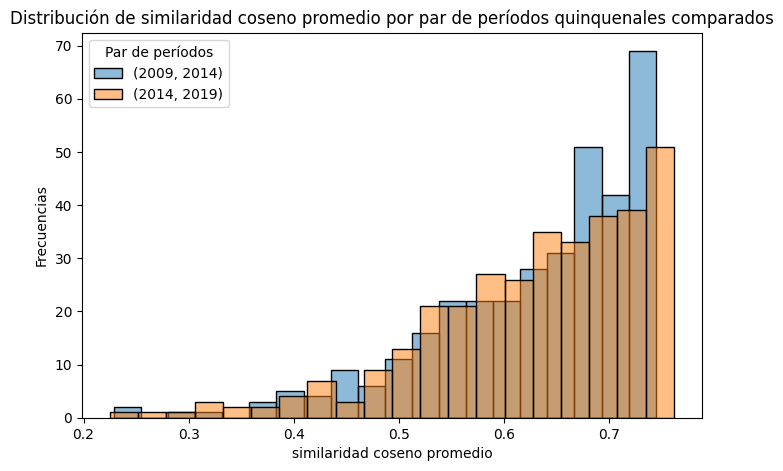

In [4]:
pares_periodo = [ (2009, 2014),(2014, 2019)]
topk = 10
plt.figure(figsize=(8, 5))
for par_periodo in pares_periodo:

    df = topn_periodo[par_periodo].sort_values('similaridad_semantica_mean', ascending=True)
    print("*************************")
    print(par_periodo)
    print("*************************")
    print(df.shape)
    #display(df.head(topk))
    display(df.describe(include='all'))
    ax= sns.histplot(data=df, x='similaridad_semantica_mean', label=str(par_periodo), common_norm=False, bins=20, alpha=0.5)
    ax.set(xlabel='similaridad coseno promedio', ylabel='Frecuencias')
plt.title("Distribución de similaridad coseno promedio por par de períodos quinquenales comparados")
plt.legend(title='Par de períodos')

* Par de períodos (2009, 2014)
    * 345 palabras
    * Similaridad coseno promedio
        * media: 0.630022
        * mediana: 0.657978

* Par de períodos (2014, 2019)
    * 337 palabras
    * Similaridad coseno promedio
        * media: 0.629155 	
        * mediana: 0.646712

**Los resultados generales indican que, para cada par de períodos analizados, la media de la similaridad coseno promedio entre vectores de palabras supera el umbral de 0.6, lo cual sugiere una relativa estabilidad semántica en el uso del lenguaje legislativo vinculado a la salud**

### Distribución entre períodos


Para determinar que una palabra tiene cambio semántico entre los pares de periodos comparados (período 2009 vs período 2014 y período 2014 vs período 2019) se debe garantizar que :
* Se identifica la palabra como palabra consistentemente cambiantes en alguno de los pares de períodos comparados.
* El promedio de similaridad coseno asociado a la palabra es menor a 0.5 tal que:
    * Cambio fuerte: promedio de similaridad coseno  < 0.3
    * Cambio moderado: promedio de similaridad coseno entre 0.3 y 0.5

In [5]:


# Convertir datos en DataFrame para visualización
def plot_heatmap(cambios_df, title, top = 10):
    #words, values = zip(*changed_words[:top])  # Tomamos el top 10
    #df = pd.DataFrame({"Palabra": words, "Cambio Semántico": values})
    df = cambios_df.copy()
    plt.figure(figsize=(8, 5))
    sns.heatmap(df.set_index("palabra").T, cmap="Reds", annot=True, fmt=".2f", linewidths=0.5)
    plt.title(title)
    plt.show()

def diferencia(par):
    return par[1] - par[0]

 Promedio de similaridad coseno  <= 0.3 , Cambio fuerte (usos muy distintos)


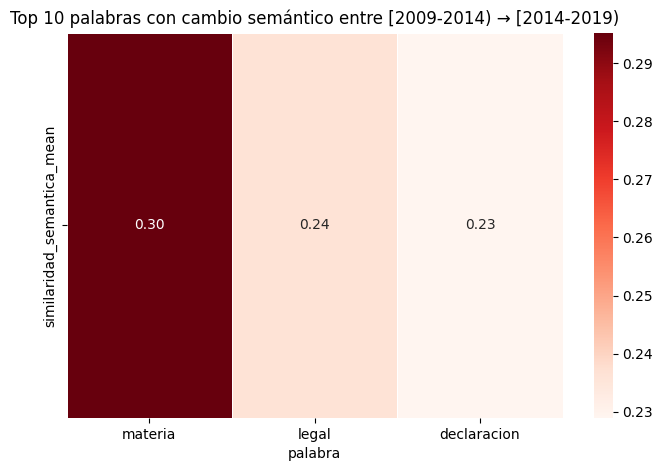

TOP 10 Palabras: ['materia' 'legal' 'declaracion']


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10,vt1_top10_union,vt2_top10_union,dispersion
198,"(2009, 2014)",materia,0.295281,"(0.28972409518941494, 0.30129455440205416)","{fortalecimiento, primaria, delito, estr, adopcion, presupuesto, postraumatico, basica}","{congreso, cumplimiento, politica, vacunacion, laboratorio}","{adopcion, fortalecer, censo, fortalecimiento, primaria, minimo, delito, estr, prostata, financiero, objetivo, presupuesto, postraumatico, basica}","{cumplimiento, domiciliario, vacunacion, fiebre, laboratorio, voluntario, trabajo, consentimiento, area, produccion, congreso, violencia, pobreza, agropecuario, economico, observatorio, muerte, politica, vencido, obligacion}",0.011570
187,"(2009, 2014)",legal,0.236390,"(0.22927847455041062, 0.24318201364083122)","{odontologia, musicoterapia, loteria, norma, colaborador, obstetricia, auxiliar}","{monodroga, droga, misoprostol, embarazo}","{capitulo, trabajador, ocupacional, expendio, odontologia, ejercicio, musicoterapia, loteria, fitoterapicos, colaborador, obstetricia, norma, terapeuta, auxiliar, eliminacion, terapista, cosmetologo}","{planta, droga, domiciliario, aplv, terapia, recoleccion, instrumento, formulacion, embarazo, aptitud, calendario, fitoterapicos, malformacion, menor, produccion, laser, tipo, monodroga, edad, misoprostol, medicamento, fabricacion, fetal, cirugia, distribucion, vegetal, ftalato, medicamentosa, vencido, realizacion, mercurio}",0.013904
81,"(2009, 2014)",declaracion,0.228949,"(0.21734069298480946, 0.23947355413807772)","{jujuy, rioja, valle, accion, natural, departamento, vital, chaco}","{prepagar, marco, valor, comision, suspension}","{espinal, clinico, jujuy, accion, departamento, vital, ochenta, alergia, plazo, estr, epidemiologico, chaco, mendoza, cordoba, isla, rio, rioja, valle, natural, pedro}","{federal, listado, lectivo, prepagar, exigencia, marco, valor, evaluacion, afiliado, comision, requisito, maternidad, inssjp, pobreza, pami, mayo, medicina, suspension}",0.022133


Promedio de similaridad coseno  <= 0.5  Cambio moderado


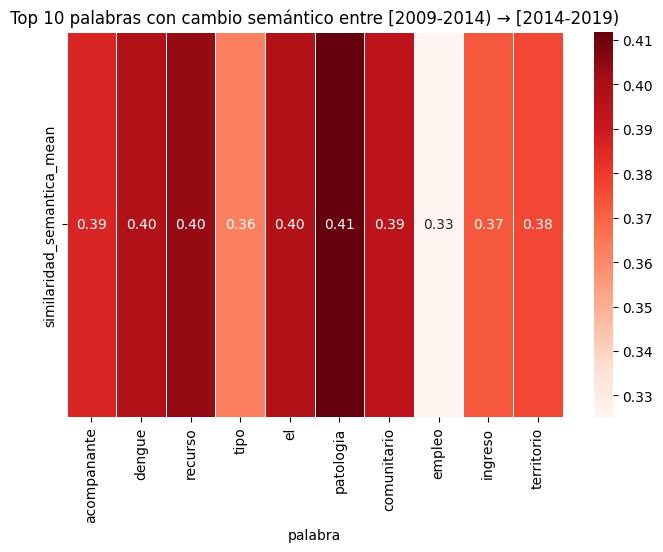

TOP 10 Palabras: ['acompanante' 'dengue' 'recurso' 'tipo' 'el' 'patologia' 'comunitario'
 'empleo' 'ingreso' 'territorio']


,par_periodo,palabra,similaridad_semantica_mean,vt1_top10,vt2_top10,vt1_top10_union,vt2_top10_union,dispersion,similaridad_semantica_confidence_intervals
4,"(2009, 2014)",acompanante,0.385782,"{gratuidad, embarazo, proceso, permanencia, recien, nacimiento, parto}","{recurso, cosmetologia, cosmiatrio, perforacion, piercing, obstetricia, equinoterapia, terapeutico}","{nacido, mujer, primario, colegio, embarazo, privado, relacion, permanencia, maternidad, nacimiento, violencia, proceso, recien, puerperio, mistanasica, gratuidad, consultoria, reconstruccion, situacion, parto}","{tatuaj, recurso, tecnico, cosmiatrio, cosmetologia, ejercicio, perforacion, piercing, obstetricia, equinoterapia, terapeutico}",0.013096,"(0.3796140793051261, 0.3927100810180494)"
84,"(2009, 2014)",dengue,0.397421,"{ochenta, aparicion, tropical, epidemia, territorio, emergente, seguimiento, chaco}","{fiebre, nosocomial, virus, comprendido}","{ochenta, aparicion, causado, cordoba, tropical, epidemia, prioritario, sanitario, territorio, emergente, represa, demencia, medioambiental, seguimiento, chaco}","{digno, vacuna, nosocomial, ninez, virus, lectivo, transcurso, intrahospitalaria, comprendido, paliativo, pediculosis, nocivo, vacunacion, fiebre, alzheimer, cerebrovascular, tumor}",0.013304,"(0.3906659951600832, 0.40396962671954595)"
284,"(2009, 2014)",recurso,0.403970,"{tecnologico, verificacion, tecnico, aptitud, superior, trazabilidad, enfermeria, pandemia}","{acompanante, acvo, obstetricia, equinoterapia, terapeutico, acv, cerebrovascular}","{gripe, tecnologico, verificacion, tecnico, aptitud, superior, trazabilidad, periodico, afiliado, enfermeria, pandemia, seguro}","{acompanante, artriti, tatuaj, acvo, promover, cosmiatrio, cosmetologia, perforacion, piercing, obstetricia, equinoterapia, terapeutico, acv, cerebrovascular, reumatoidea}",0.015942,"(0.3957360371918691, 0.4116778499043911)"
327,"(2009, 2014)",tipo,0.362660,"{gripe, aparicion, virus, influenza, causado, papiloma, avance, h1n1}","{droga, cualquiera, ensenanza, fabricacion}","{gripe, aparicion, virus, causado, influenza, papiloma, neumococo, cobro, avance, asistencial, varicela, pandemia, h1n1, incremento, hpv}","{nomenclador, vacuna, distribucion, legal, deportivo, droga, cualquiera, ensenanza, importacion, medicamentosa, fabricacion, instrumento, mercurio, organo}",0.016245,"(0.35430114554481895, 0.3705464389172895)"
111,"(2009, 2014)",el,0.397509,"{juvenil, septiembre, regional, rioja, infeccion, infanto, identificar, hidrogenado}","{septiembre, clinico, premio, doctor, consentimiento}","{septiembre, regional, juvenil, aceite, rioja, ciudad, febrero, infeccion, identificar, infanto, autorizar, hidrogenado}","{clinico, premio, julio, monohidratado, historia, inter, consentimiento, nacimiento, creatin, respectivamente, septiembre, monodroga, comercializacion, doctor, prohibir, sol, informado, distribucion, enfermo, octubre, recetado}",0.016423,"(0.38912091958821676, 0.4055441278858894)"
240,"(2009, 2014)",patologia,0.411828,"{mamario, mastectomia, reconstruccion, producido, partos, mamaria, nocivo, puerperio, cirugia, radiacion}","{nacido, visual, recien}","{mamario, mastectomia, reconstruccion, producido, partos, mamaria, nocivo, puerperio, cirugia, radiacion}","{espinal, braille, nacido, etiqueta, recoleccion, ame, oximetria, formulacion, calendario, visual, comprendido, infanto, neonatal, basico, comercializacion, gastrointestinal, recien, juvenil, pulso, oftalmologico, eosinofilico, vencido, atrofia, diverso}",0.016693,"(0.4031071651262161, 0.4197998237966619)"
65,"(2009, 2014)",comunitario,0.394368,"{hogar, voluntario, militar, sanitaria, revestir, radicacion, direccion}","{familia, accion, financiero, julio, marzo}","{hogar, adiccion, voluntario, militar, familia, sanitaria, observatorio, revestir, empleo, radicacion, jefe, direccion, monto}","{digno, odontologia, marco, accion, comision, financiero, julio, desarrollo, primaria, febrero, valor, mental, maternidad, marzo, mayo, ninez,

 Promedio de similaridad coseno  <= 0.3 , Cambio fuerte (usos muy distintos)


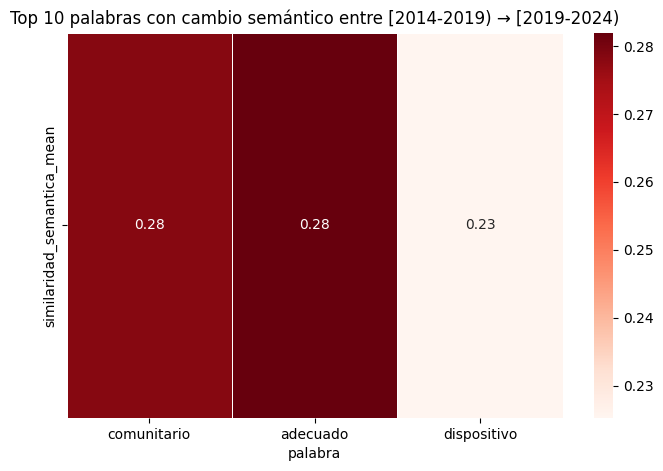

TOP 10 Palabras: ['comunitario' 'adecuado' 'dispositivo']


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10,vt1_top10_union,vt2_top10_union,dispersion
68,"(2014, 2019)",comunitario,0.278242,"(0.27209223779084657, 0.28498834537825385)","{familia, accion, financiero, julio, marzo}","{trabajador, organizacion, fortalecimiento, reconocimiento, escolar, objeto, agente, presupuesto}","{digno, odontologia, marco, accion, comision, financiero, julio, desarrollo, primaria, febrero, valor, mental, maternidad, marzo, mayo, ninez, adiccion, fortalecimiento, doctor, prestacion, familia, enfermo, enero, paliativo, natural, mes, organismo, medicina}","{trabajador, estetico, grasa, organizacion, asignacion, fortalecimiento, cuyo, reconocimiento, comida, complejidad, escolar, obstetricia, objeto, agente, presupuesto, corporal, modificatoria, tumor}",0.012896
5,"(2014, 2019)",adecuado,0.281939,"(0.27380922948631065, 0.29072955279423457)","{rotulacion, especialidad, medicinal, camara}","{congreso, geriatrico, manejo, paliativo, hijo, tumor}","{jugo, farmaceutico, codigo, porcentaje, alcohol, gasificado, circuito, modificatoria, guarderia, composicion, potable, alimentario, profesion, camara, capitulo, cadena, television, especialidad, rotulacion, frio, medicinal}","{digno, dato, ejecutivo, geriatrico, manejo, funcion, agente, provincial, modificatoria, nomenclador, mama, congreso, hijo, pais, paliativo, situacion, diabetes, procreacion, tumor}",0.016920
102,"(2014, 2019)",dispositivo,0.225310,"(0.21517525682306737, 0.23474702168764897)","{dato, similar, nocivo, necesario, electronico}","{instalacion, tecnologico, oftalmologico, concurrencia, subitar, minimo, desfibrilador}","{digital, braille, necesario, sufrir, incorporar, dato, leches, transgenico, comprendido, efecto, medicamentosa, fabricacion, implementacion, receta, correspondiente, electronico, similar, nocivo}","{cartel, instalacion, tecnologico, aplicacion, oftalmologico, concurrencia, examen, subitar, lugar, minimo, comprendido, desfibrilador, agua, gratuito, pobreza, argentina, radiacion}",0.019572


Promedio de similaridad coseno  <= 0.5  Cambio moderado


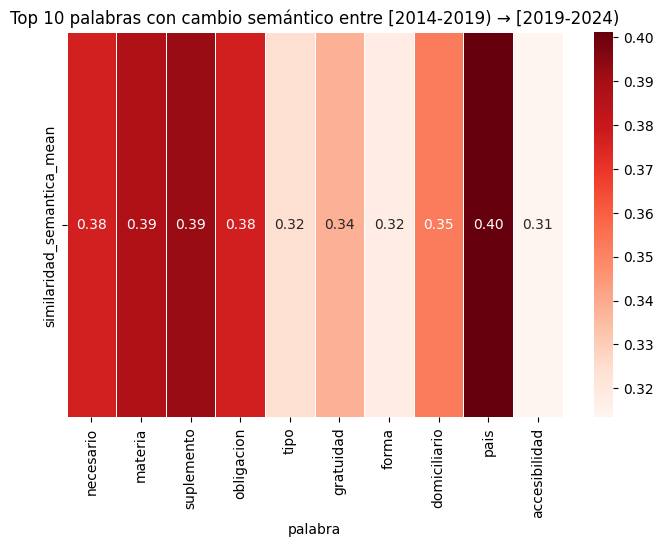

TOP 10 Palabras: ['necesario' 'materia' 'suplemento' 'obligacion' 'tipo' 'gratuidad'
 'forma' 'domiciliario' 'pais' 'accesibilidad']


,par_periodo,palabra,similaridad_semantica_mean,vt1_top10,vt2_top10,vt1_top10_union,vt2_top10_union,dispersion,similaridad_semantica_confidence_intervals
226,"(2014, 2019)",necesario,0.376819,"{concurrencia, subitar, desfibrilador, dispositivo, existir, precio}","{publicitario, principio, precio}","{concurrencia, incorporar, externo, subitar, automatico, diabetico, desfibrilador, comida, muerte, dispositivo, existir, area, realizacion, fetal, masivo, precio}","{llamado, mujer, vino, garantizar, aplv, terapia, precio, publicitario, principio, manejo, norma, importacion, malformacion, cronico, produccion, acv, oporto, misoprostol, vascular, comercializacion, dengue, grupo, reproduccion, proteina, alzheimer, mancha}",0.014051,"(0.36968563011637146, 0.3837369113647057)"
203,"(2014, 2019)",materia,0.387141,"{congreso, cumplimiento, politica, vacunacion, laboratorio}","{zona, sexual, periodo, infeccion, prorrogable, vih}","{cumplimiento, domiciliario, vacunacion, fiebre, laboratorio, voluntario, trabajo, consentimiento, area, produccion, congreso, violencia, pobreza, agropecuario, economico, observatorio, muerte, politica, vencido, obligacion}","{adiccion, desastre, periodo, sexual, zona, consumo, plazo, infeccion, prorrogable, abril, vih, chaco}",0.015209,"(0.3795103875474098, 0.3947197528161688)"
311,"(2014, 2019)",suplemento,0.392070,"{dietario, monohidratado, creatin, habilitado}","{leche, etiquetado, libre}","{transcurso, mujer, gratuito, instrumento, publicitario, grasa, monohidratado, farmacia, habilitado, elaboracion, gestion, creatin, elemento, dietario, comercializacion, exclusivo, sol, sodio, lectivo, lent, recetado, mercurio}","{periodo, articulo, fiebre, codigo, fumar, etiquetado, alcohol, sangre, materia, venta, exhibicion, alimentario, tabaco, leche, numerir, lactancia, destinado, prorrogable, mes, elaborado, libre}",0.017554,"(0.38343898329763293, 0.4009932622711729)"
233,"(2014, 2019)",obligacion,0.377334,"{congreso, farmaceutico, especialidad, cumplimiento, profesion}","{donante, sangre, animal, judicial, alcoholica}","{cadena, licenciado, principio, congreso, farmaceutico, especialidad, adecuado, afiliado, cumplimiento, otorgar, profesion, frio, obstetricia, medicinal, receta, terapeutico, suspension}","{respectivamente, listado, donante, envase, obra, prepagar, etiqueta, dato, alcoholica, solar, banco, sangre, animal, judicial, rehabilitacion, primario, organo}",0.018112,"(0.3676906106188161, 0.38580297248050355)"
319,"(2014, 2019)",tipo,0.324483,"{droga, cualquiera, ensenanza, fabricacion}","{braille, droga, visual, judicial, identificacion, diabetes}","{nomenclador, vacuna, distribucion, legal, deportivo, droga, cualquiera, ensenanza, importacion, medicamentosa, fabricacion, instrumento, mercurio, organo}","{braille, capacidad, pensionado, droga, secundario, visual, afectar, tecnica, sustitucion, animal, judicial, trasplantado, identificacion, primario, condicion, diabetes}",0.018273,"(0.31554016370582855, 0.3338127264717762)"
159,"(2014, 2019)",gratuidad,0.338310,"{vacunacion, vacuna, calendario}","{pensionado, jubilado, potable, ter, agua, presupuesto}","{psicologico, resolucion, vacunacion, fiebre, implante, sufrir, calendario, comprendido, infanto, area, asiento, vacuna, administracion, venerea, radiacion, juvenil, oftalmologico, paciente, ensenanza, estatal, otorgar, profilaxis, medicamentosa}","{especial, ter, financiero, agua, medida, pensionado, agente, trabajador, minimo, potable, afiliado, instituto, dependencia, afectado, genetico, publico, presupuesto, consecuencia, jubilado}",0.018883,"(0.32870270818783265, 0.3475855696532716)"
150,"(2014, 2019)",forma,0.317746,"{proteina, transmision, cualquiera, complemento}","{modelo, organizacion, actualizacion, domiciliario, correspondiente}","{derivado, oximetria, adiccion, pulso, complemento, etiqueta, examen, cualquiera, proteina, transmision, tecnica, relacionado, hospital, investigacion, gratuito, apto, biomedico}","{modelo, fisico, ter, domiciliario, pub

In [6]:
topk = 10
for par_periodo in pares_periodo:

    print(" Promedio de similaridad coseno  <= 0.3 , Cambio fuerte (usos muy distintos)")
    periodo_df = topn_periodo[par_periodo]
    umbral_fuerte1 = 0.3
    periodo_df1 =  periodo_df[periodo_df['similaridad_semantica_mean']<=umbral_fuerte1].sort_values('similaridad_semantica_mean', ascending=True).head(topk)
    periodo_df1["dispersion"] = periodo_df1['similaridad_semantica_confidence_intervals'].apply(diferencia)
    periodo_df1 =  periodo_df1.sort_values('dispersion', ascending=True)

    # Graficar Heatmaps
    plot_heatmap(periodo_df1[['palabra','similaridad_semantica_mean']], "Top 10 palabras con cambio semántico entre ["+str(par_periodo[0])+"-"+str(par_periodo[1])+") → ["+str(par_periodo[1])+"-"+str(par_periodo[1]+5)+")", top=topk)
    print("TOP 10 Palabras:", periodo_df1['palabra'].unique())
    display(periodo_df1) 
    print("Promedio de similaridad coseno  <= 0.5  Cambio moderado")

    umbral_fuerte2 = 0.5
    periodo_df1 =  periodo_df[(periodo_df['similaridad_semantica_mean']<=umbral_fuerte2) & (periodo_df['similaridad_semantica_mean']>umbral_fuerte1)].sort_values('similaridad_semantica_mean', ascending=True).head(topk)
    periodo_df1["dispersion"] = periodo_df1['similaridad_semantica_confidence_intervals'].apply(diferencia)
    periodo_df1 =  periodo_df1.sort_values('dispersion', ascending=True)

    # Graficar Heatmaps
    plot_heatmap(periodo_df1[['palabra','similaridad_semantica_mean']], "Top 10 palabras con cambio semántico entre ["+str(par_periodo[0])+"-"+str(par_periodo[1])+") → ["+str(par_periodo[1])+"-"+str(par_periodo[1]+5)+")", top=topk)
    print("TOP 10 Palabras:", periodo_df1['palabra'].unique())
    display(periodo_df1[['par_periodo', 	'palabra', 	'similaridad_semantica_mean' 	,'vt1_top10' 	,'vt2_top10', 	'vt1_top10_union' 	,'vt2_top10_union', 	'dispersion','similaridad_semantica_confidence_intervals' 	]])  

#### Análisis técnico y contextual palabra por palabra, considerando:

* El valor promedio de similaridad coseno (similaridad_semantica_mean): cuanto más bajo, mayor cambio semántico.

* El contenido de las vecindades (vt1_top10, vt2_top10) por intersección de 50 iteraciones.

* Las vecindades por unión (vt1_top10_union, vt2_top10_union) como panorama más amplio del contexto semántico.

* La dispersión, que indica variabilidad en las 50 iteraciones.

#### 🔴Palabras con cambio semántico fuerte
**Par de período (2009, 2014)**
* 'materia' : con promedio de similaridad coseno 0.295281
    * Vecindades 2009: asociadas a educación básica y temas sociales ("primaria", "basica", "adopcion", "delito", "presupuesto").
    * Vecindades 2014: giran a implementación sanitaria y regulatoria ("vacunación", "cumplimiento", "laboratorio", "congreso").
    * el término materia pasa de ser usado en contexto educativo y social a uno vinculado a materias legislativas sanitarias o normativas, 
	lo que sugiere una resemantización institucional?

      
* 'legal': con promedio de similaridad coseno 0.236390
    * Vecindades 2009: relacionadas con profesiones de salud ("musicoterapia", "auxiliar", "obstetricia", "odontología").
    * Vecindades 2014: pasan a vincularse con medicación, aborto, regulación farmacéutica ("misoprostol", "monodroga", "droga").
    * legal deja de usarse en contextos de ejercicio profesional y pasa a adquirir fuerte carga bioética y política, particularmente en temas como la interrupción voluntaria del embarazo o acceso a medicamentos. Este tipo de cambio es especialmente relevante para estudios de controversias legislativas en salud pública?

  
* 'declaracion': con promedio de similaridad coseno 0.228949
    * Vecindades 2009: indican un uso vinculado a lugares geográficos y reconocimiento cultural o natural ("jujuy", "chaco", "natural","valle", "vital").
    * Vecindades 2014: se asocian a ámbitos administrativos y de seguridad social ("prepagar", "valor", "comisión", "suspension").
    * declaración deja de referirse a "declarar algo de interés" (como una zona o evento) para adoptar un sentido más técnico, normativo, incluso relacionado con prestaciones de salud, programas y regulación de cobertura.

**Par de período (2014, 2019)**
* 'comunitario': con promedio de similaridad coseno 0.278242
    * Vecindad 2014: palabras vinculadas al ámbito familiar o social como familia, financiero, marzo, julio, acción.
    * Vecindad 2019: aparecen nuevos términos asociados a lo institucional, lo escolar y a funciones estatales: organización, agente, trabajador, presupuesto, reconocimiento, fortalecimiento.
    * el término "comunitario" se desplaza desde un uso más sociofamiliar hacia un uso más vinculado a actores estatales, programas escolares y planificación institucional, lo que puede reflejar un cambio de enfoque en políticas públicas o legislativas.?

* 'adecuado': con promedio de similaridad coseno 0.2819
    * Vecindad 2014: relacionada a cuestiones técnicas y normativas, como especialidad, rotulación, medicinal.
    * Vecindad 2019: cambia a temas más asistenciales y sociales, con palabras como manejo, geriátrico, paliativo, tumor, hijo.
    * el término cambia de un uso asociado a la calidad regulatoria o técnica hacia uno relacionado con la atención sanitaria directa, especialmente en poblaciones vulnerables (personas mayores, hijos). Esto puede vincularse a un aumento en propuestas de ley sobre calidad del cuidado?

* 'dispositivo': con promedio de similaridad coseno 0.2253
    * Vecindad 2014: se asocia a nocivo, electrónico, dato, similar, es decir, un enfoque en riesgos o regulación tecnológica.
    * Vecindad 2019: surge su vínculo con temas de salud pública y equipamiento médico, como desfibrilador, subitar, concurrencia, instalación, oftalmológico.
    * el término "dispositivo" se aleja de la idea de artefacto tecnológico genérico o riesgoso hacia una interpretación más sanitaria y concreta, posiblemente reflejando políticas de equipamiento (por ejemplo, desfibriladores en espacios públicos)?



#### 🟡Palabras con cambio semántico moderado
**Par de período (2009, 2014)**

* 'acompañante': similaridad coseno promedio		0.3858	Cambio de contexto social a técnico-terapéutico?.
    * Vecindades 2009: gratuidad, parto, embarazo, recien, nacimiento.
    * Vecindades 2014: terapeutico, cosmetologia, equinoterapia, obstetricia.
    * Cambio de un acompañante en contexto reproductivo a uno terapéutico y técnico. Puede indicar nuevas regulaciones sobre prácticas no médicas (piercing, cosmiatría)?

* 'dengue': similaridad coseno promedio0.3974	Reorientación del foco epidemiológico y léxico.
    * Vecindades 2009: territorio, emergente, epidemia, chaco.
    * Vecindades 2014: virus, fiebre, nosocomial.
    * Cambio de narrativa desde brotes geográficos a diagnóstico clínico y prevención.?

* 'recurso': similaridad coseno promedio 0.4040	De formación técnica a uso médico-terapéutico.
    * Vecindades 2009: tecnologico, tecnico, pandemia, enfermeria, trazabilidad.
    * Vecindades 2014: equinoterapia, cerebrovascular, acv, acompanante.
    * La noción de “recurso” se reorienta desde un enfoque estructural a uno terapéutico, posiblemente por reformas en atención médica.

* 'tipo': similaridad coseno promedio	0.3627	Cambios en clasificación y aplicaciones sanitarias.
    * Vecindades 2009: virus, gripe, H1N1, papiloma.
    * Vecindades 2014: fabricación, droga, ensenanza.

* el	: similaridad coseno promedio0.3975	Cambio sutil, tal vez más formal o técnico.
* patología: similaridad coseno promedio	0.4118	De cáncer y puerperio a neonatología.
    * Vecindades 2009: cirugia, puerperio, mastectomia, radiacion.
    * Vecindades 2014: visual, recien, nacido .
    * Cambio desde patologías adultas/femeninas a pediátricas o visuales, lo que podría reflejar nuevos focos de política sanitaria?

* 'comunitario': similaridad coseno promedio	0.3944	
    * Vecindades 2009: militar, sanitaria, hogar, voluntario.
    * Vecindades 2014: familia, financiero, marzo, julio.
    * Cambio de “comunitario” desde enfoque territorial o estatal o sociofamiliar.?

* 'empleo': similaridad coseno promedio	0.3252	De contexto familiar a legal-normativo.
    * Vecindades 2009: familia, hogar, jefe .
    * Vecindades 2014: asignacion, subsistema, sustancia.
    * Cambio desde definición familiar de empleo a empleo como objeto de política o regulación?.

* 'ingreso': similaridad coseno promedio	0.3727	Cambio de política social a categorías en estudio.
    * Vecindades 2009: ANSES, ninez, ciudadadano, geriatrico.
    * Vecindades 2014: ninez, categoria, maquinaria.
    * Cambio de “ingreso” como beneficio a categoría en estudios.?


* 'territorio': similaridad coseno promedio	0.3765	De asociado ambiente y quimico a institucionalidad geográfica.
    * Vecindades 2009: lavandería,tintorería, percloroetileno.
    * Vecindades 2014: natural, republica .

**Par de período (2009, 2014)**

* 'necesario' : similaridad coseno promedio 0.377
    * Vecindad 2014: subitar, existir, concurrencia, dispositivo, desfibrilador, precio
    * Vecindad 2019: precio, publicitario, principio
    * En 2014, “necesario” aparece asociado a emergencias médicas, dispositivos como el DEA (desfibrilador), y muerte súbita.En 2019, se conecta con principios normativos y regulación comercial (precio, publicitario). De urgencia sanitaria a estándares y acceso regulado?.

* 'materia' : similaridad coseno promedio 0.387
    * Vecindad 2014: vacunación, política, congreso
    * Vecindad 2019: infección, vih, periodo, sexual, zona
    * Cambia de un contexto político-institucional y normativo hacia uno más relacionado con salud sexual y enfermedades transmisibles.Implica que “materia” pasó de ser usada en “materia legislativa de salud” a temas vinculados a prevención de infecciones y VIH?

* 'suplemento': similaridad coseno promedio 0.392
    * 2014: dietario, creatin, monohidratado
    * 2019: etiquetado, libre, leche
    * De un contexto centrado en nutrición o clínica especializada, a normativas de etiquetado o lactancia . Refleja un giro hacia la alimentación saludable como política pública.?

* 'obligación': similaridad coseno promedio 0.377
    * Vecindad en 2014: cumplimiento, congreso, farmaceutico, especialidad, profesion.
    * Vecindad en 2019: alcoholica, donante, animal, judicial, sangre
    * En 2014 los términos que hacen foco en el cumplimiento normativo, institucionalidad y el rol profesional (e.g., médicos, farmacéuticos). Para 2019, vira hacia temas de riesgo, responsabilidad judicial, donación y bioética. En 2014 la palabra obligación se usaba más para referirse a roles institucionales (profesionales, cumplimiento). En 2019 su uso se desplazó hacia temas sensibles y ético-legales, como donación de órganos, acceso a tratamientos, responsabilidad judicial.?

* 'tipo': similaridad coseno promedio 0.324
    * 2014: fabricación, cualquiera, droga, enseñanza
    * 2019: diabetes, identificación, judicial, visual
    * Cambio de categoría genérica o tecnológica (tipo de droga, tipo de educación) a tipos de condiciones de salud y accesibilidad (braille, judicial, diabetes).

* 'gratuidad' : similaridad coseno promedio 0.338
    * 2014: vacunación, calendario
    * 2019: jubilado, ter, potable, presupuesto
    * De acceso gratuito a vacunas hacia una noción más amplia de gratuidad como derecho para grupos vulnerables (jubilados, agua potable, genetico)?.

* 'forma': : similaridad coseno promedio 0.318
    * 2014: transmisión, cualquiera, proteína, complemento
    * 2019: modelo, organización, domiciliario
    * Gira desde un uso biomédico o bioquímico hacia un enfoque sobre la forma de prestación y acceso a la atención (atención domiciliaria, organización del sistema)?.

* 'domiciliario' : similaridad coseno promedio 0.352
    * 2014: recolección, vencido, resolución, inssjp
    * 2019: financiero, forma, educación, ter
    * Evoluciona desde aspectos técnicos/logísticos (residuos, medicamentos vencidos) hacia el cuidado domiciliario como modalidad de atención educativa y médica.?

* país : similaridad coseno promedio 0.401
    * 2014: desfibrilador, deber, acreditar
    * 2019: ejecutivo, instalación, ciudadano
    * Transición desde una perspectiva de infraestructura sanitaria (instalación de dispositivos) hacia un uso político-institucional, ligado a autoridad, derecho y regulación nacional?.

* accesibilidad : similaridad coseno promedio0.313)
    * 2014: discapacitada, movilidad, consentimiento
    * 2019: dato, trabajo, gestion, digno
    * Pasa de un enfoque en barreras físicas o de movilidad hacia temas más sistémicos y administrativos (gestión de datos, derechos laborales, dignidad).?



*Estos cambios permiten*

* Detectar reorientaciones en las prioridades discursivas del Congreso.

* Entender cómo ciertos términos como acompañante, recurso, territorio se adaptan a nuevos marcos legales o institucionales.

* Servir de insumo para organizaciones que monitorean derechos y acceso a salud, alertando sobre cambios sutiles en el lenguaje parlamentario que pueden reflejar transformaciones más profundas.

##### Palabras comunes en entre todos los períodos


In [7]:
palabra_comun = set(topn_periodo[(2009, 2014)]['palabra'].unique()) & set(topn_periodo[(2014, 2019)]['palabra'].unique())
print("Cantidad de palabras en común:",len(palabra_comun))

Cantidad de palabras en común: 274


In [8]:
# Período (2009, 2014)
df = topn_periodo[(2009, 2014)]
df = df[df['palabra'].isin(palabra_comun)]
df = df[['palabra','similaridad_semantica_mean','similaridad_semantica_confidence_intervals','vt1_top10','vt2_top10']]
df.columns = ['palabra','ss_mean_2009_2014','ss_ci_2009_2014','vt1_top10_2009_2014','vt2_top10_2009_2014']

# Período (2014, 2019)
df2 = topn_periodo[(2014, 2019)]
df2 = df2[df2['palabra'].isin(palabra_comun)]
df2 = df2[['palabra','similaridad_semantica_mean','similaridad_semantica_confidence_intervals','vt1_top10','vt2_top10']]
df2.columns = ['palabra','ss_mean_2014_2019','ss_ci_2014_2019','vt1_top10_2014_2019','vt2_top10_2014_2019']

# Unión
df = df.merge(df2, how='inner', on='palabra')
df = df[['palabra', 'ss_mean_2009_2014', 'ss_mean_2014_2019', 'ss_ci_2009_2014','ss_ci_2014_2019','vt1_top10_2009_2014','vt2_top10_2009_2014', 'vt1_top10_2014_2019','vt2_top10_2014_2019']]
df['peso'] = (df['ss_mean_2009_2014'] + df['ss_mean_2014_2019'] )/2
df['diferencia'] = abs(df['ss_mean_2009_2014'] - df['ss_mean_2014_2019'] )

print("Top 10 de palabras comunes con fuerte cambio semántco entre Período [2009, 2014) - > [2014, 2019)  ")
print("Palabras:",df[df['peso']<=0.3].sort_values('peso').head(10)['palabra'].unique() )
display(df[df['peso']<=0.3].sort_values('peso').head(10))
print("Top 10 de palabras comunes con moderado cambio semántco entre Período [2009, 2014) - > [2014, 2019)  ")
print("Palabras:",df[(df['peso']>0.3) & (df['peso']<=0.5)].sort_values('peso').head(10)['palabra'].unique() )
display(df[(df['peso']>0.3) & (df['peso']<=0.5)].sort_values(['peso','diferencia']).head(10))

Top 10 de palabras comunes con fuerte cambio semántco entre Período [2009, 2014) - > [2014, 2019)  
Palabras: []


,palabra,ss_mean_2009_2014,ss_mean_2014_2019,ss_ci_2009_2014,ss_ci_2014_2019,vt1_top10_2009_2014,vt2_top10_2009_2014,vt1_top10_2014_2019,vt2_top10_2014_2019,peso,diferencia


Top 10 de palabras comunes con moderado cambio semántco entre Período [2009, 2014) - > [2014, 2019)  
Palabras: ['comunitario' 'materia' 'tipo' 'legal' 'ingreso' 'gratuidad' 'argentina'
 'domiciliario' 'necesario' 'obligacion']


,palabra,ss_mean_2009_2014,ss_mean_2014_2019,ss_ci_2009_2014,ss_ci_2014_2019,vt1_top10_2009_2014,vt2_top10_2009_2014,vt1_top10_2014_2019,vt2_top10_2014_2019,peso,diferencia
54,comunitario,0.394368,0.278242,"(0.3854192976683241, 0.40313915747436657)","(0.27209223779084657, 0.28498834537825385)","{hogar, voluntario, militar, sanitaria, revestir, radicacion, direccion}","{familia, accion, financiero, julio, marzo}","{familia, accion, financiero, julio, marzo}","{trabajador, organizacion, fortalecimiento, reconocimiento, escolar, objeto, agente, presupuesto}",0.336305,0.116126
166,materia,0.295281,0.387141,"(0.28972409518941494, 0.30129455440205416)","(0.3795103875474098, 0.3947197528161688)","{fortalecimiento, primaria, delito, estr, adopcion, presupuesto, postraumatico, basica}","{congreso, cumplimiento, politica, vacunacion, laboratorio}","{congreso, cumplimiento, politica, vacunacion, laboratorio}","{zona, sexual, periodo, infeccion, prorrogable, vih}",0.341211,0.091860
258,tipo,0.362660,0.324483,"(0.35430114554481895, 0.3705464389172895)","(0.31554016370582855, 0.3338127264717762)","{gripe, aparicion, virus, influenza, causado, papiloma, avance, h1n1}","{droga, cualquiera, ensenanza, fabricacion}","{droga, cualquiera, ensenanza, fabricacion}","{braille, droga, visual, judicial, identificacion, diabetes}",0.343572,0.038177
156,legal,0.236390,0.544586,"(0.22927847455041062, 0.24318201364083122)","(0.5367409556444638, 0.5524675364778583)","{odontologia, musicoterapia, loteria, norma, colaborador, obstetricia, auxiliar}","{monodroga, droga, misoprostol, embarazo}","{monodroga, droga, misoprostol, embarazo}","{estetico, beneficiario, misoprostol, obstetricia, ingreso}",0.390488,0.308196
147,ingreso,0.372726,0.412960,"(0.36275331038413855, 0.383107578577557)","(0.40638691279749256, 0.419535943999969)","{ninez, ciudadano, geriatrico, anses, fincini, ganancia, basico}","{maquina, ninez, virus, categoria, solar}","{maquina, ninez, virus, categoria, solar}","{beneficiario, pensionado, fortalecimiento, jubilado, otorgar, indice, primario}",0.392843,0.040234
128,gratuidad,0.519763,0.338310,"(0.5108354225421323, 0.5281449193363955)","(0.32870270818783265, 0.3475855696532716)","{acompanante, rotavirus, indirecto, proceso, permanencia, directo, prohibir, nacimiento}","{vacunacion, vacuna, calendario}","{vacunacion, vacuna, calendario}","{pensionado, jubilado, potable, ter, agua, presupuesto}",0.429037,0.181453
23,argentina,0.442295,0.437635,"(0.436044236520672, 0.44842712913052624)","(0.42690586000537556, 0.4475896708366713)","{chagas, limitacion, prioritario, comercializado, bioetica, riesgo, republica, cigarrillo}","{tecnologico, erupcion, natural, comision, objeto, volcan, basico, republica}","{tecnologico, erupcion, natural, comision, objeto, volcan, basico, republica}","{prevenibl, tecnologia, desfibrilador, evaluacion, pobreza, republica}",0.439965,0.004659
85,domiciliario,0.530396,0.352300,"(0.5232490962499607, 0.5373275994736747)","(0.34218341901493204, 0.3632497526569617)","{capacidad, odontologico, vencido, instrumento, partos, recoleccion, mercurio, civil, peligroso}","{recoleccion, inssjp, vencido, resolucion}","{recoleccion, inssjp, vencido, resolucion}","{educacion, organizacion, ter, forma, financiero, trasplantado}",0.441348,0.178095
184,necesario,0.511345,0.376819,"(0.502066570851367, 0.5204022468271262)","(0.36968563011637146, 0.3837369113647057)","{medicacion, ostomizada, olivia, presupuesto, incluyendolo}","{concurrencia, subitar, desfibrilador, dispositivo, existir, precio}","{concurrencia, subitar, desfibrilador, dispositivo, existir, precio}","{publicitario, principio, precio}",0.444082,0.134526
190,obligacion,0.534139,0.377334,"(0.5251409580361376, 0.5424780460585731)","(0.3676906106188161, 0.38580297248050355)","{willi, posibilidad, spw, existir, prader, cromosomatico}","{congreso, farmaceutico, especialidad, cumplimiento, profesion}","{congreso, farmaceutico, especialidad, cumplimiento, profesion}","{donante, sangr

* Cantidad de palabras en común: 274
* Las 10 palabras comunes entre pares de periodos comparados consecutivos con mayor peso de cambio semántico moderado son
 ['comunitario' 'materia' 'tipo' 'legal' 'ingreso' 'gratuidad' 'argentina'
 'domiciliario' 'necesario' 'obligacion'] .El peso es el promedio de similaridad coseno promedio para los pares de períodos comparados.

    * No aparece 'declaracion', pero aparecen ['legal' 'materia'] de las palabras de fuerte cambio semántico en (2009-2014). En relación a cambio semántico de las palabras identificadas con cambio moderado, solo aparecen en palabras en comunes 'tipo' e 'ingreso' y 'comunitario'. ['acompanante' 'dengue' 'recurso' 'el' 'patologia' 'empleo' 'territorio'].
    * No aparecen ['dispositivo', 'adecuado'], pero aparece 'comunitario' de las palabras de fuerte cambio semantico en (2014-2019).En relación a cambio semántico de las palabras identificadas con cambio moderado, solo aparecen en palabras en comunes 'tipo', 'gratuidad', 'domiciliario', 'obligacion' , 'necesario' , y  'materia'. No aparecen ['forma' 'pais' 'accesibilidad'].
    * La palabra 'argentina' aparece entre las palabas de cambio moderado, cuando antes no estaba en top 10.
    * Las palabras 'legal' y "materia" pasaron de un cambio fuerte en primer par de periodos a moderado en segundo par de periodos. Mientras que  'comunitario' paso de cambio moderado en primer par de periodos a fuerte en segundo par de periodos

TOP 10 Palabras 
Par período (2009,2014): 
* Fuerte:  ['materia' 'legal' 'declaracion']
* Moderado: ['acompanante' 'dengue' 'recurso' 'tipo' 'el' 'patologia' 'comunitario','empleo' 'ingreso' 'territorio']

Par período (2014,2019): 
* Fuerte: ['comunitario' 'adecuado' 'dispositivo']
* Moderado: ['necesario' 'materia' 'suplemento' 'obligacion' 'tipo' 'gratuidad',  'forma' 'domiciliario' 'pais' 'accesibilidad']




#### Identificar vecindades de palabras

La vecindad de una palabra, son las N palabras más asociadas al período quinquinal observado. Por ejemplo: la palabra 'dispositivo' en el período 2014 estaba más asociado a las palabras {electronico, similar, dato, nocivo} tal para el período 2019 estaba más relacionado con {desfibrilador, instalacion, tecnologico, subitar, concurrencia}.

Se busca las n palabras más similares (por similut coseno) a una palabra objetivo y así poder interpretar el posible cambio semantico. Para más información: https://tedboy.github.io/nlps/generated/generated/gensim.models.Word2Vec.most_similar.html

In [9]:
# Directorio con modelo de embedding alineados por procrustes correspondiente a i = 0
alin_dir = modelo_dir +'/estabilidad_procrustes/alineado/'
i = 0

In [10]:
# Inicializar estructura de vectores por palabra
from collections import defaultdict
vectores_por_palabra = {}
vectores_promedio = {}

def get_vector_modelo(vectores,periodo,i):
    modelo = Word2Vec.load(alin_dir+"alin_" + str(periodo)+'_'+str(i)+'.mdl')
    for palabra in modelo.wv.key_to_index:
        vectores[palabra].append(modelo.wv[palabra])
    return vectores
    
for periodo in [2009,2014,2019]:
    # Por período
    vectores_por_palabra[periodo] = defaultdict(list)
    for i in range(50):
        vectores_por_palabra[periodo] = get_vector_modelo(vectores_por_palabra[periodo],periodo,i)
    #Calcular vector medio solo para palabras con presencia en todas las iteraciones (opcional)
    vectores_promedio[periodo] = {pal: np.mean(vs, axis=0) for pal, vs in vectores_por_palabra[periodo].items() if len(vs) == 50}

In [11]:
## 2. Visualización del desplazamiento con t-SNE
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine


def compute_cosine_similarity(model1,model2,word):
    vector1 = model1.wv[word].reshape(1,-1)
    vector2 = model2.wv[word].reshape(1,-1)
    return(cosine_similarity(X=vector1, Y=vector2)[0][0])

def reducir_dimensionalidad( embeddings, n_components=2, perplexity=5, palabrasComun = []):
    if len(palabrasComun)>0:
        words = palabrasComun
    else:
        words = list(embeddings.keys())
    
    vectors = np.array([embeddings.wv.get_vector(word)  for word in words])
    #embeddings[word]  
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=42)
    reduced_vectors = tsne.fit_transform(vectors)
    
    return reduced_vectors



def plot_neighbors_tsne(word, embeddings_by_period, alineados=None, periods=None, top_k=10):

    all_vectors, all_labels, all_colors = [], [], []
    center_positions = {}

    # Paleta accesible para daltonismo
    color_palette = sns.color_palette("colorblind", len(periods))

    for i, period in enumerate(periods):
        if word not in embeddings_by_period[period]:
            print(f"'{word}' no está en el vocabulario del período {period}")
            continue

        vocab = embeddings_by_period[period]

        if alineados:
            vecinos = alineados[period].wv.most_similar(positive=[word], topn=top_k)
            print(period)
            print(vecinos)
            neighbors = [w for w, _ in vecinos] + [word]
        else:
            vecinos = sorted(
                vocab.items(),
                key=lambda kv: cosine(vocab[word], kv[1])
            )[1:top_k+1]
            neighbors = [w for w, _ in vecinos] + [word]

        for w in neighbors:
            all_vectors.append(vocab[w])
            all_labels.append(w)
            all_colors.append(color_palette[i])

    if all_vectors:
        tsne = TSNE(n_components=2, perplexity=5, random_state=0)
        X_2d = tsne.fit_transform(np.array(all_vectors))

        plt.figure(figsize=(16, 10))
        ax = plt.gca()
        ax.set_facecolor('white')  # Fondo blanco
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_visible(True)

        for i, (x, label) in enumerate(zip(X_2d, all_labels)):
            plt.scatter(x[0], x[1], color=all_colors[i], s=70, edgecolor='black', linewidth=0.6)
            fontsize = 14 if label == word else 11
            weight = 'bold' if label == word else 'normal'

            # Separación de etiquetas: se desplazará ligeramente del punto
            offset = 1 if label == word else 0.5
            plt.text(x[0] + offset, x[1] + offset, label, fontsize=fontsize,
                     fontweight=weight, color='black',
                     bbox=dict(facecolor='white', edgecolor='none', pad=0.2))

        # Identificar y trazar los centros
        index = 0
        for i, period in enumerate(periods):
            if word in embeddings_by_period[period]:
                center_positions[period] = X_2d[index + top_k]
                index += top_k + 1

        # Flechas de cambio semántico
        for i in range(len(periods) - 1):
            p1, p2 = periods[i], periods[i+1]
            if p1 in center_positions and p2 in center_positions:
                start, end = center_positions[p1], center_positions[p2]
                plt.arrow(start[0], start[1], end[0]-start[0], end[1]-start[1],
                          color='gray', linewidth=1.5, head_width=0.5, length_includes_head=True)

                mid_x = (start[0] + end[0]) / 2
                mid_y = (start[1] + end[1]) / 2
                plt.text(mid_x, mid_y, f'{p2}', fontsize=10, ha='center',
                         va='center', backgroundcolor='white')

        # Leyenda
        for i, period in enumerate(periods):
            plt.scatter([], [], color=color_palette[i], label=str(period))
        plt.legend(title='Período', loc='upper left', fontsize=11)

        plt.title(f"Evolución semántica de '{word}' por quinquenios", fontsize=16, weight='bold')
        plt.axis('off')  # Mostrar bordes del gráfico
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.savefig(modelo_dir+'/estabilidad_procrustes/estabilidad_procrustes_'+word)
        plt.tight_layout()
        plt.show()
        plt.clf()       # Limpia el contenido actual de la figura
        plt.close()     # Cierra la figura actual

In [12]:
# Para graficar
i = 0
vectores_alineados = {}
modelos_alineados = {}
vocab = {}
for periodo in [2009,2014,2019]:
    modelo = Word2Vec.load(alin_dir+"alin_" + str(periodo)+'_'+str(i)+'.mdl')
    vocab = {word: modelo.wv.get_vector(word) for word in modelo.wv.key_to_index}  # NUEVO vocab cada vez
    vectores_alineados[periodo]=  vocab
    modelos_alineados[periodo] = modelo

**Enfoque de explorar la iteración 0**

In [13]:
top10pal_comunes_df = df.sort_values(['peso']).head(10)
top10pal = list(top10pal_comunes_df['palabra'].values)
top10pal

['comunitario',
 'materia',
 'tipo',
 'legal',
 'ingreso',
 'gratuidad',
 'argentina',
 'domiciliario',
 'necesario',
 'obligacion']

In [14]:
top10pal_comunes_df

,palabra,ss_mean_2009_2014,ss_mean_2014_2019,ss_ci_2009_2014,ss_ci_2014_2019,vt1_top10_2009_2014,vt2_top10_2009_2014,vt1_top10_2014_2019,vt2_top10_2014_2019,peso,diferencia
54,comunitario,0.394368,0.278242,"(0.3854192976683241, 0.40313915747436657)","(0.27209223779084657, 0.28498834537825385)","{hogar, voluntario, militar, sanitaria, revestir, radicacion, direccion}","{familia, accion, financiero, julio, marzo}","{familia, accion, financiero, julio, marzo}","{trabajador, organizacion, fortalecimiento, reconocimiento, escolar, objeto, agente, presupuesto}",0.336305,0.116126
166,materia,0.295281,0.387141,"(0.28972409518941494, 0.30129455440205416)","(0.3795103875474098, 0.3947197528161688)","{fortalecimiento, primaria, delito, estr, adopcion, presupuesto, postraumatico, basica}","{congreso, cumplimiento, politica, vacunacion, laboratorio}","{congreso, cumplimiento, politica, vacunacion, laboratorio}","{zona, sexual, periodo, infeccion, prorrogable, vih}",0.341211,0.091860
258,tipo,0.362660,0.324483,"(0.35430114554481895, 0.3705464389172895)","(0.31554016370582855, 0.3338127264717762)","{gripe, aparicion, virus, influenza, causado, papiloma, avance, h1n1}","{droga, cualquiera, ensenanza, fabricacion}","{droga, cualquiera, ensenanza, fabricacion}","{braille, droga, visual, judicial, identificacion, diabetes}",0.343572,0.038177
156,legal,0.236390,0.544586,"(0.22927847455041062, 0.24318201364083122)","(0.5367409556444638, 0.5524675364778583)","{odontologia, musicoterapia, loteria, norma, colaborador, obstetricia, auxiliar}","{monodroga, droga, misoprostol, embarazo}","{monodroga, droga, misoprostol, embarazo}","{estetico, beneficiario, misoprostol, obstetricia, ingreso}",0.390488,0.308196
147,ingreso,0.372726,0.412960,"(0.36275331038413855, 0.383107578577557)","(0.40638691279749256, 0.419535943999969)","{ninez, ciudadano, geriatrico, anses, fincini, ganancia, basico}","{maquina, ninez, virus, categoria, solar}","{maquina, ninez, virus, categoria, solar}","{beneficiario, pensionado, fortalecimiento, jubilado, otorgar, indice, primario}",0.392843,0.040234
128,gratuidad,0.519763,0.338310,"(0.5108354225421323, 0.5281449193363955)","(0.32870270818783265, 0.3475855696532716)","{acompanante, rotavirus, indirecto, proceso, permanencia, directo, prohibir, nacimiento}","{vacunacion, vacuna, calendario}","{vacunacion, vacuna, calendario}","{pensionado, jubilado, potable, ter, agua, presupuesto}",0.429037,0.181453
23,argentina,0.442295,0.437635,"(0.436044236520672, 0.44842712913052624)","(0.42690586000537556, 0.4475896708366713)","{chagas, limitacion, prioritario, comercializado, bioetica, riesgo, republica, cigarrillo}","{tecnologico, erupcion, natural, comision, objeto, volcan, basico, republica}","{tecnologico, erupcion, natural, comision, objeto, volcan, basico, republica}","{prevenibl, tecnologia, desfibrilador, evaluacion, pobreza, republica}",0.439965,0.004659
85,domiciliario,0.530396,0.352300,"(0.5232490962499607, 0.5373275994736747)","(0.34218341901493204, 0.3632497526569617)","{capacidad, odontologico, vencido, instrumento, partos, recoleccion, mercurio, civil, peligroso}","{recoleccion, inssjp, vencido, resolucion}","{recoleccion, inssjp, vencido, resolucion}","{educacion, organizacion, ter, forma, financiero, trasplantado}",0.441348,0.178095
184,necesario,0.511345,0.376819,"(0.502066570851367, 0.5204022468271262)","(0.36968563011637146, 0.3837369113647057)","{medicacion, ostomizada, olivia, presupuesto, incluyendolo}","{concurrencia, subitar, desfibrilador, dispositivo, existir, precio}","{concurrencia, subitar, desfibrilador, dispositivo, existir, precio}","{publicitario, principio, precio}",0.444082,0.134526
190,obligacion,0.534139,0.377334,"(0.5251409580361376, 0.5424780460585731)","(0.3676906106188161, 0.38580297248050355)","{willi, posibilidad, spw, existir, prader, cromosomatico}","{congreso, farmaceutico, especialidad, cumplimiento, profesion}","{congreso, farmaceutico, especialidad, cumplimiento, profesion}","{donante, sangr

Las gráficas siguientes nos permiten visualizar cómo cambia el contexto semántico de una palabra específica a lo largo de periodos quinquenales, representando:
* Sus vecinos más similares (por word embeddings alineados por enfoque Procustes) en cada período.
* Su posición central (vector) en un espacio reducido a 2 dimensiones con t-SNE.
* Las flechas indican el desplazamiento del significado entre períodos.

**Para interpretar**
* Colores y períodos
    * Cada color representa un período (por ejemplo: 2009, 2014, 2019).
    * Todos los puntos del mismo color corresponden a la palabra de interés y sus vecinos en ese período.
    * Usá la leyenda para saber a qué período corresponde cada color.

* Puntos o destacados
    * El punto de la palabra clave (por ejemplo 'obligacion') suele estar con etiqueta en negrita.
    * Los vecinos más similares están alrededor, mostrando con qué palabras compartía contexto en ese momento.

* Flechas de cambio
    * Las flechas conectan el centro de cada período.
    * Muestran cómo se movió la palabra en el espacio semántico entre dos períodos consecutivos.
    * Si la dirección cambia mucho, sugiere cambio semántico fuerte.

* Distancia entre períodos
* Una distancia grande entre las posiciones de la palabra en distintos períodos sugiere cambios de significado o de contexto de uso.
* Una distancia corta indica estabilidad semántica.



2009
[('revestir', 0.822063148021698), ('militar', 0.82001793384552), ('sanitaria', 0.8149005770683289), ('radicacion', 0.7850496172904968), ('direccion', 0.7665956020355225), ('voluntario', 0.7341175675392151), ('hogar', 0.7140691876411438), ('monto', 0.6900233030319214), ('adiccion', 0.6861377954483032), ('jefe', 0.6730188727378845)]
2014
[('accion', 0.6851040720939636), ('financiero', 0.6651639938354492), ('marzo', 0.615805983543396), ('enero', 0.5907819867134094), ('julio', 0.5877232551574707), ('familia', 0.5809125900268555), ('mes', 0.5422928929328918), ('organismo', 0.5406163334846497), ('enfermo', 0.5386151671409607), ('paliativo', 0.5344851613044739)]
2019
[('agente', 0.6267890930175781), ('presupuesto', 0.6266352534294128), ('objeto', 0.6115280985832214), ('escolar', 0.5692223310470581), ('reconocimiento', 0.5691792368888855), ('organizacion', 0.5583527088165283), ('trabajador', 0.5416938662528992), ('cuyo', 0.5307914018630981), ('fortalecimiento', 0.5179105401039124), ('este

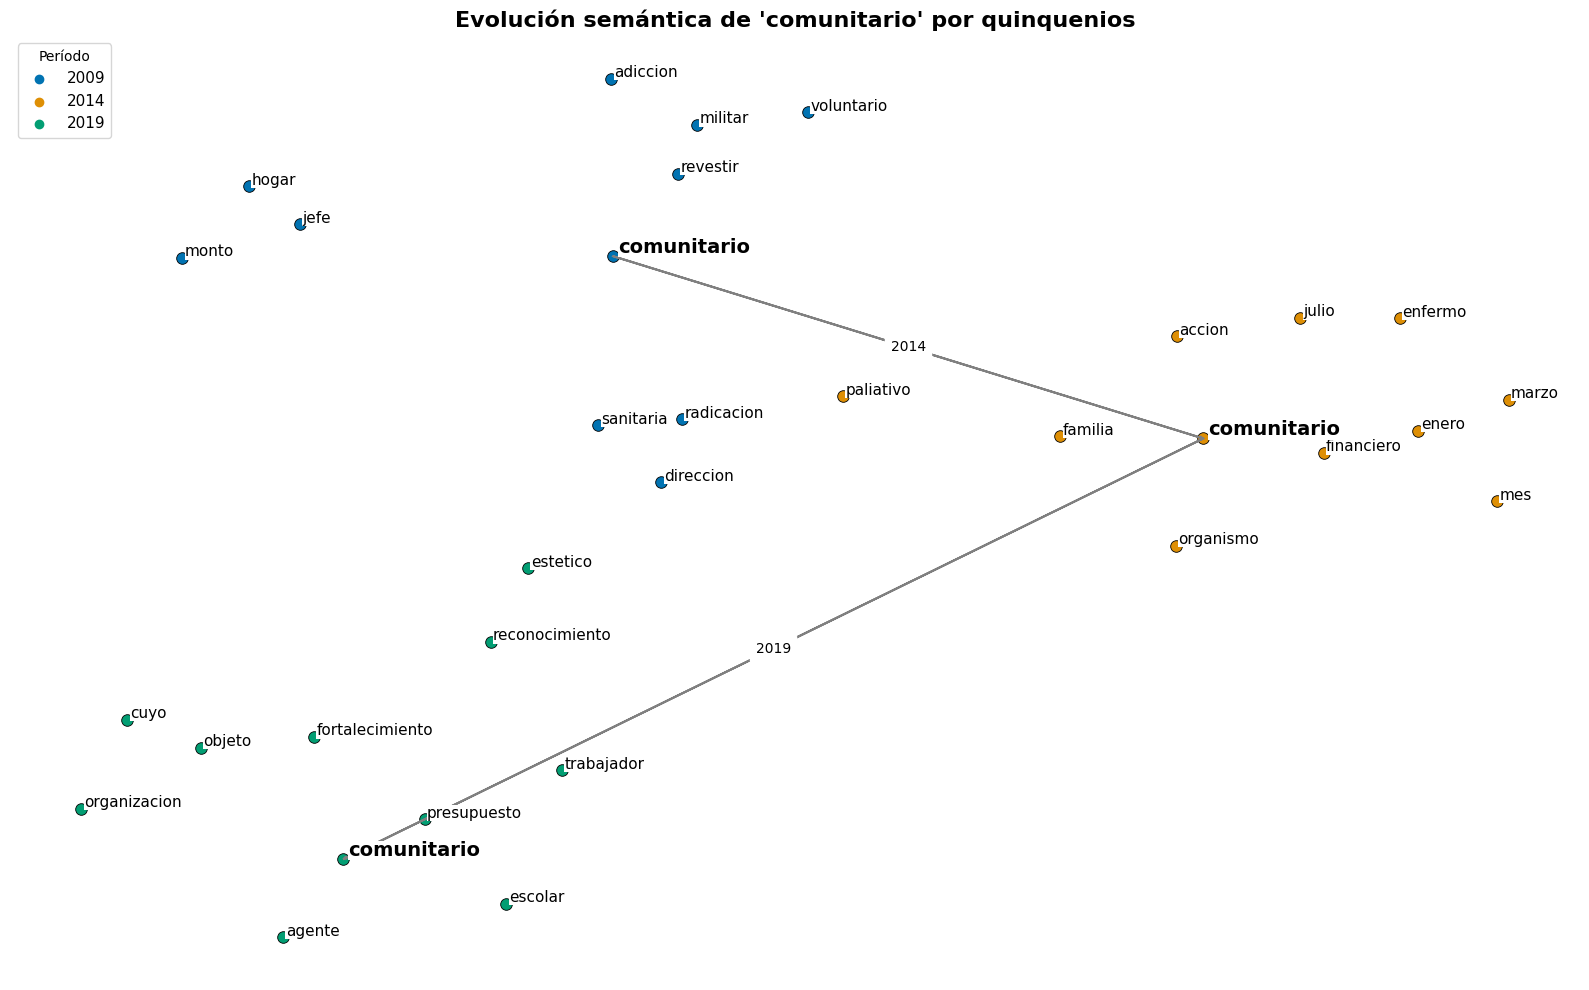

2009
[('adopcion', 0.8596965074539185), ('primaria', 0.7851497530937195), ('basica', 0.7773662805557251), ('presupuesto', 0.7367246747016907), ('postraumatico', 0.7233585715293884), ('estr', 0.7156978249549866), ('delito', 0.6895760297775269), ('fortalecimiento', 0.6858891248703003), ('objetivo', 0.6553041934967041), ('prostata', 0.6482353210449219)]
2014
[('congreso', 0.6347970962524414), ('cumplimiento', 0.5769127011299133), ('politica', 0.5658323764801025), ('vacunacion', 0.5501556992530823), ('produccion', 0.5286610722541809), ('laboratorio', 0.5150067210197449), ('muerte', 0.5074070692062378), ('economico', 0.4926636517047882), ('agropecuario', 0.4923221170902252), ('obligacion', 0.491168349981308)]
2019
[('vih', 0.7426530718803406), ('prorrogable', 0.7058641314506531), ('infeccion', 0.6786888241767883), ('periodo', 0.6519099473953247), ('sexual', 0.6312627196311951), ('zona', 0.6078023910522461), ('chaco', 0.6026772856712341), ('plazo', 0.6017365455627441), ('desastre', 0.6002461

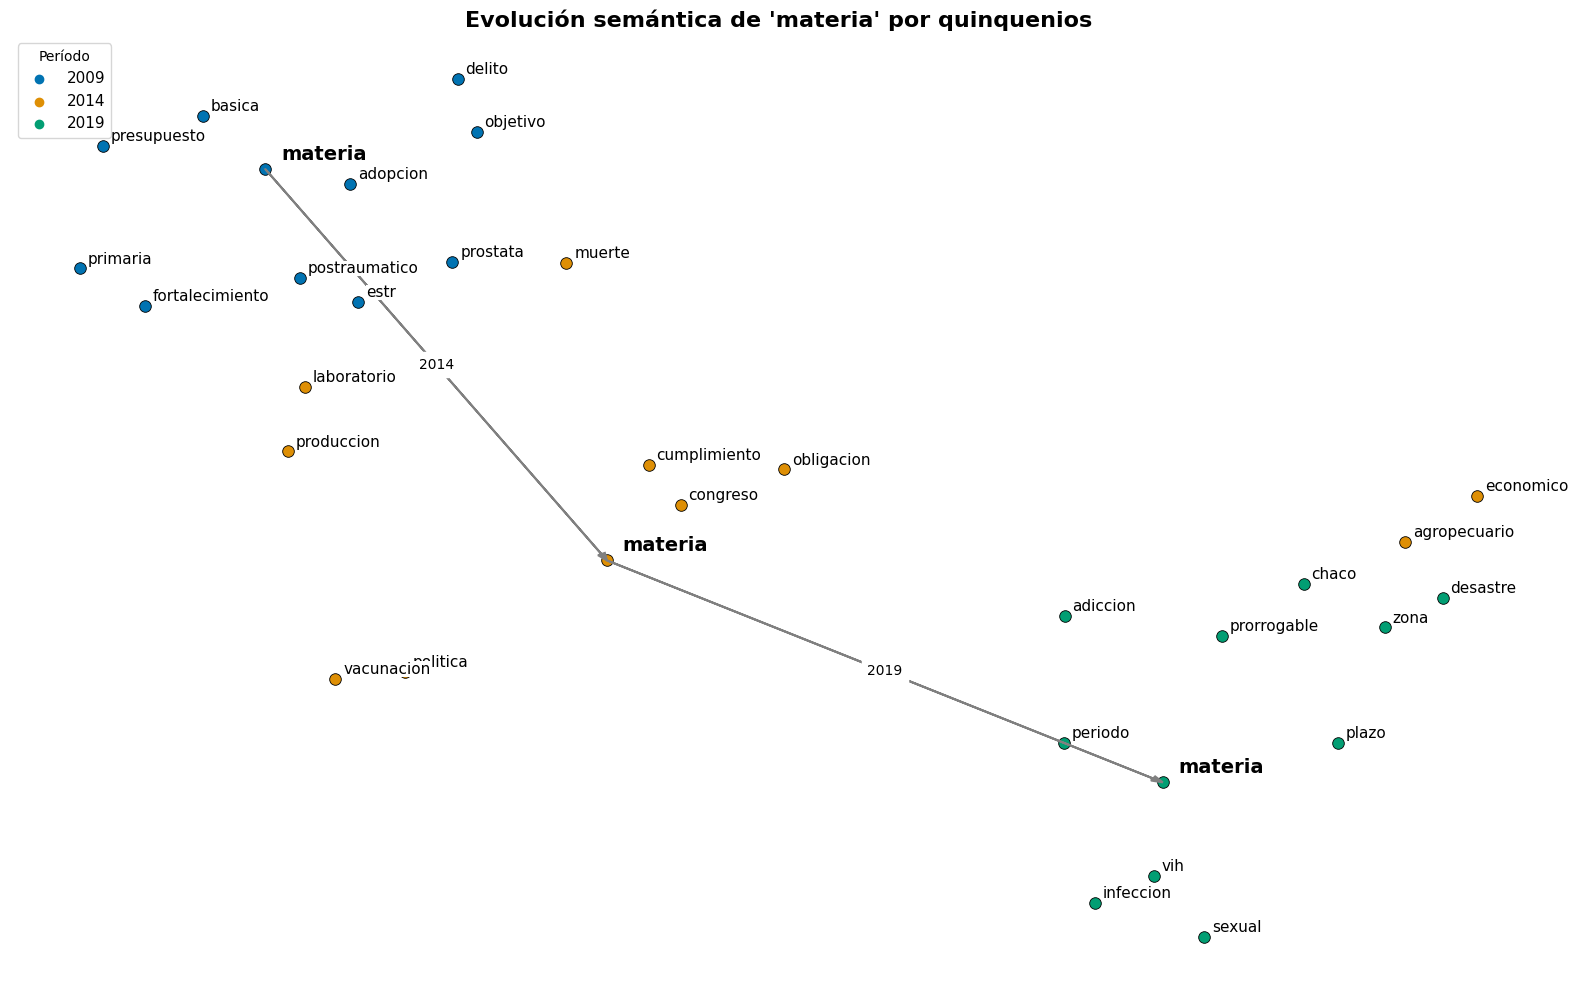

2009
[('causado', 0.7135841250419617), ('aparicion', 0.7125351428985596), ('h1n1', 0.7002319097518921), ('papiloma', 0.6889219284057617), ('gripe', 0.650924026966095), ('avance', 0.6239508986473083), ('virus', 0.6133767366409302), ('influenza', 0.5998203754425049), ('hpv', 0.599321186542511), ('neumococo', 0.5888816714286804)]
2014
[('ensenanza', 0.6783228516578674), ('cualquiera', 0.6342802047729492), ('medicamentosa', 0.5886311531066895), ('fabricacion', 0.582909107208252), ('instrumento', 0.5812655091285706), ('droga', 0.5806271433830261), ('mercurio', 0.5785053968429565), ('importacion', 0.5659635066986084), ('organo', 0.5515804886817932), ('distribucion', 0.5403341054916382)]
2019
[('droga', 0.6512472629547119), ('visual', 0.6241136789321899), ('judicial', 0.6179445385932922), ('braille', 0.5778762698173523), ('animal', 0.5766506195068359), ('identificacion', 0.5756663680076599), ('diabetes', 0.5653166174888611), ('pensionado', 0.5402799248695374), ('secundario', 0.534396409988403

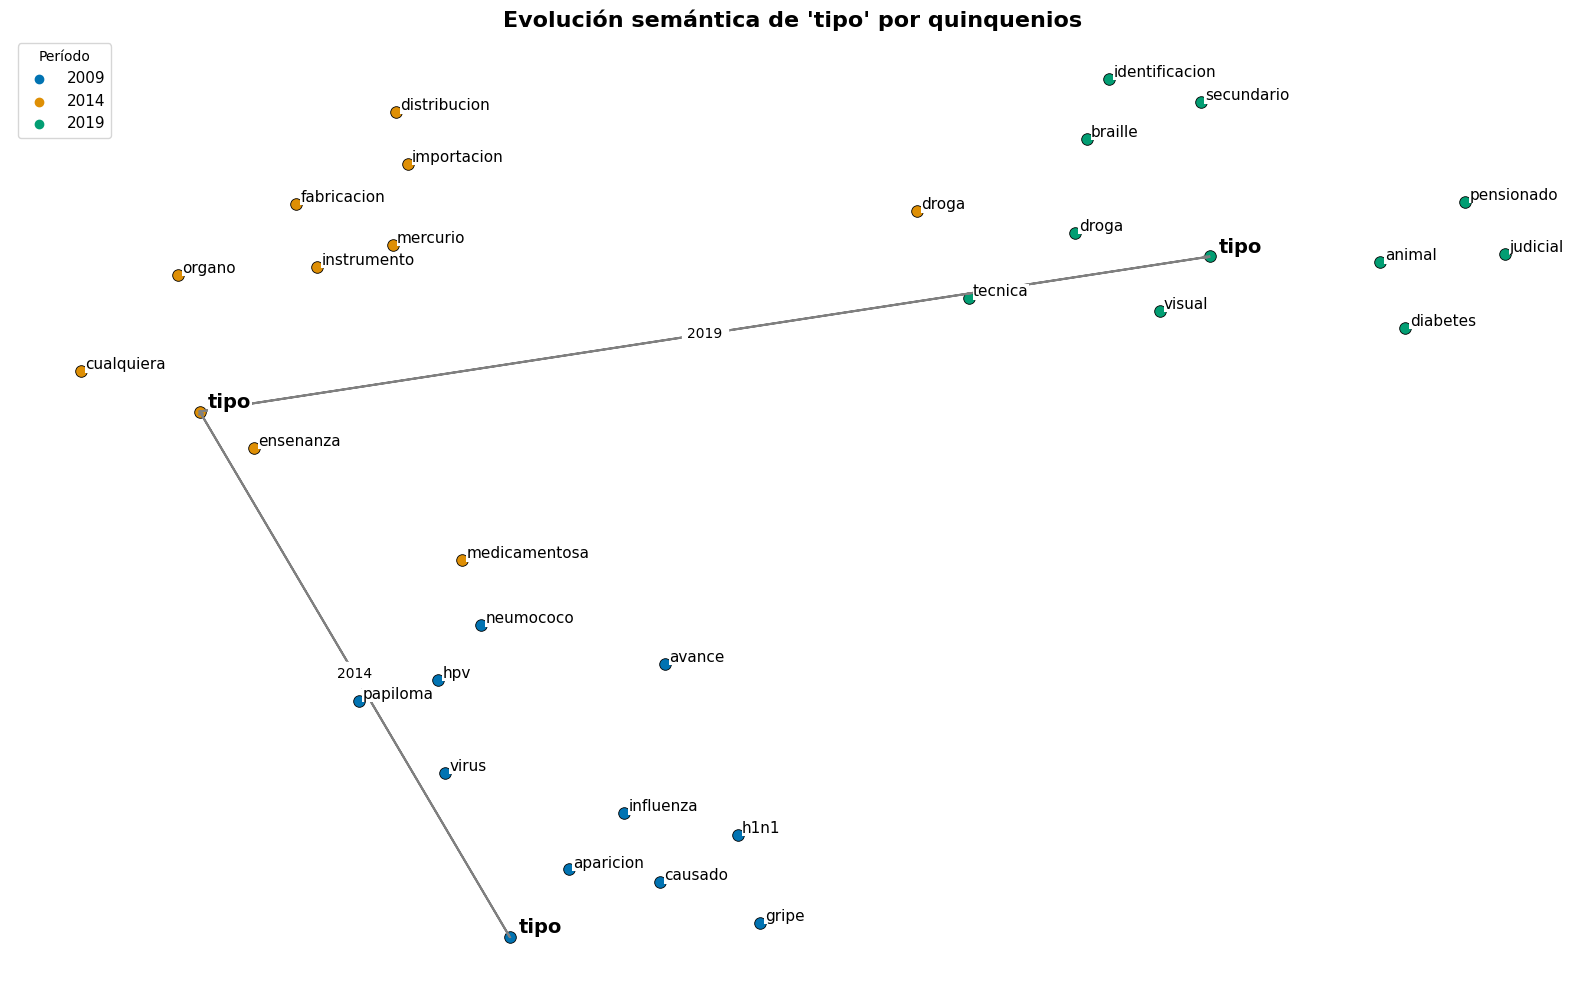

2009
[('auxiliar', 0.8725072741508484), ('loteria', 0.8547267317771912), ('odontologia', 0.8223312497138977), ('colaborador', 0.805004894733429), ('norma', 0.794803261756897), ('musicoterapia', 0.724216103553772), ('obstetricia', 0.7184157967567444), ('capitulo', 0.7147117257118225), ('fitoterapicos', 0.7020898461341858), ('ejercicio', 0.6913432478904724)]
2014
[('droga', 0.5905527472496033), ('monodroga', 0.5535401105880737), ('misoprostol', 0.5217033624649048), ('terapia', 0.5167573690414429), ('embarazo', 0.5117140412330627), ('medicamento', 0.5009921193122864), ('planta', 0.4971432685852051), ('fitoterapicos', 0.49497008323669434), ('vegetal', 0.4949137270450592), ('tipo', 0.4901314079761505)]
2019
[('obstetricia', 0.5321502089500427), ('misoprostol', 0.5250546336174011), ('estetico', 0.5132800936698914), ('beneficiario', 0.4974638819694519), ('ingreso', 0.49226292967796326), ('alcohol', 0.47484180331230164), ('habilitado', 0.4528385400772095), ('periodo', 0.4516575038433075), ('te

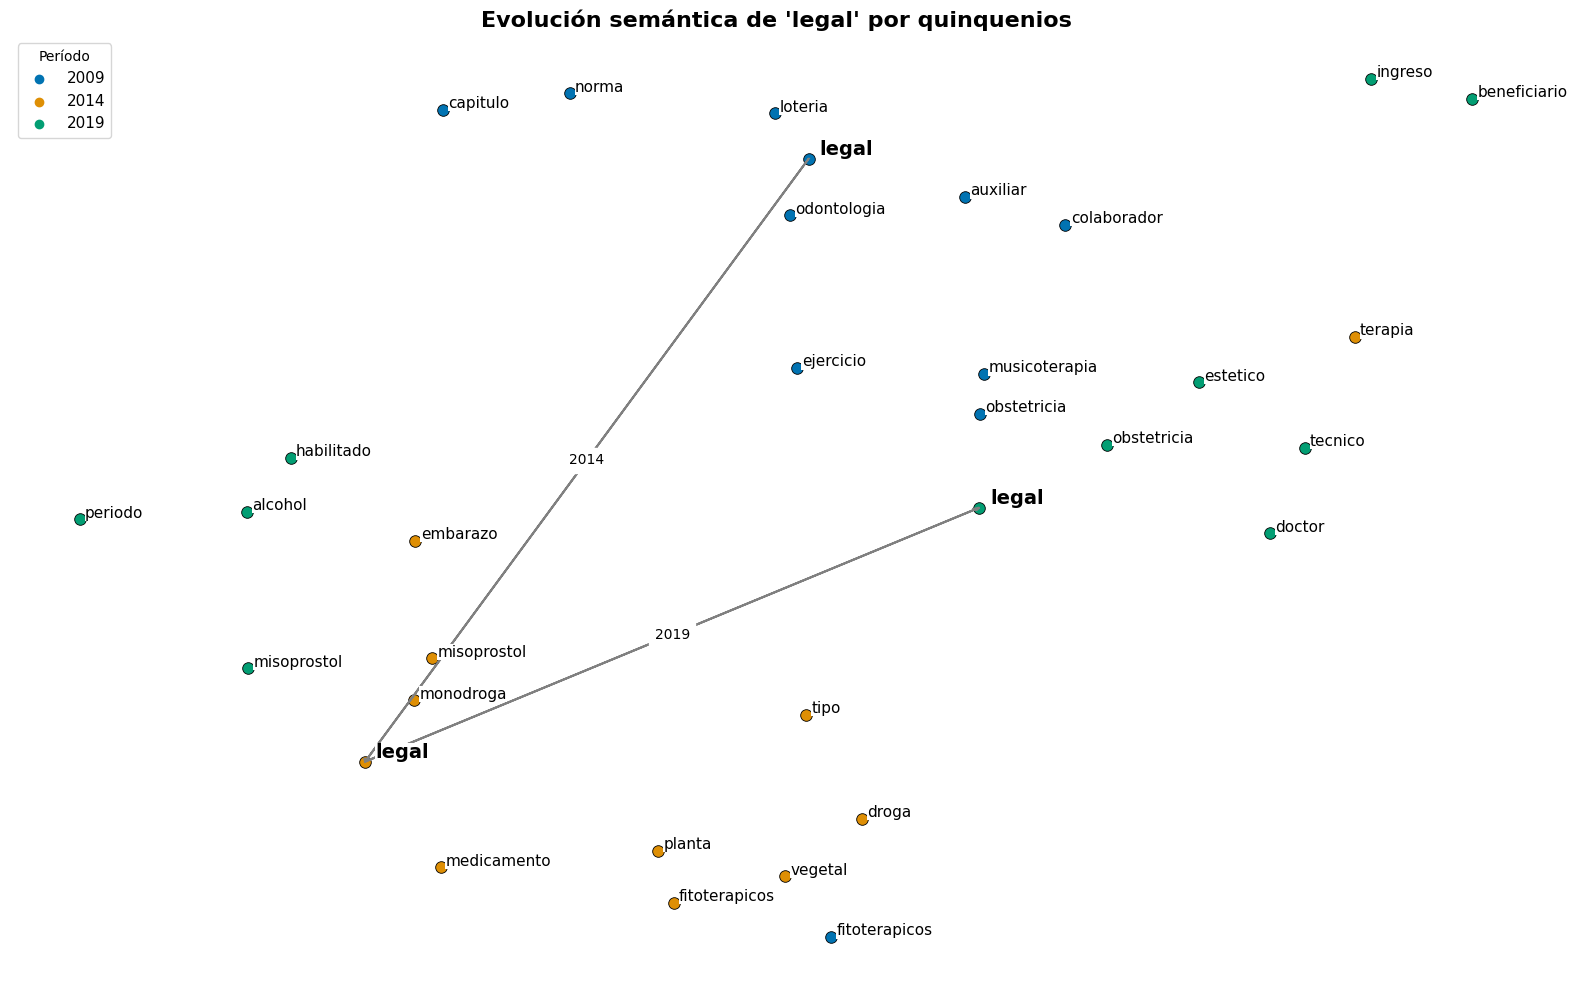

2009
[('ninez', 0.7511545419692993), ('fincini', 0.7248786091804504), ('ciudadano', 0.6414787173271179), ('ganancia', 0.6252235174179077), ('anses', 0.6103689074516296), ('geriatrico', 0.607448399066925), ('fisico', 0.5994406938552856), ('basico', 0.5984838008880615), ('ordenado', 0.5885276794433594), ('diabetes', 0.5849856734275818)]
2014
[('solar', 0.6141417622566223), ('categoria', 0.613525927066803), ('ninez', 0.5833902955055237), ('maquina', 0.5680315494537354), ('conexa', 0.5617467761039734), ('explotacion', 0.542137622833252), ('politica', 0.5416551232337952), ('virus', 0.5346400141716003), ('fiebre', 0.5097931027412415), ('pobreza', 0.5094006657600403)]
2019
[('beneficiario', 0.6749185919761658), ('pensionado', 0.6715644598007202), ('fortalecimiento', 0.6412427425384521), ('otorgar', 0.6283606886863708), ('indice', 0.5998719334602356), ('primario', 0.5993155241012573), ('jubilado', 0.5980402231216431), ('entidad', 0.5900365114212036), ('afiliado', 0.5797289609909058), ('ter', 0

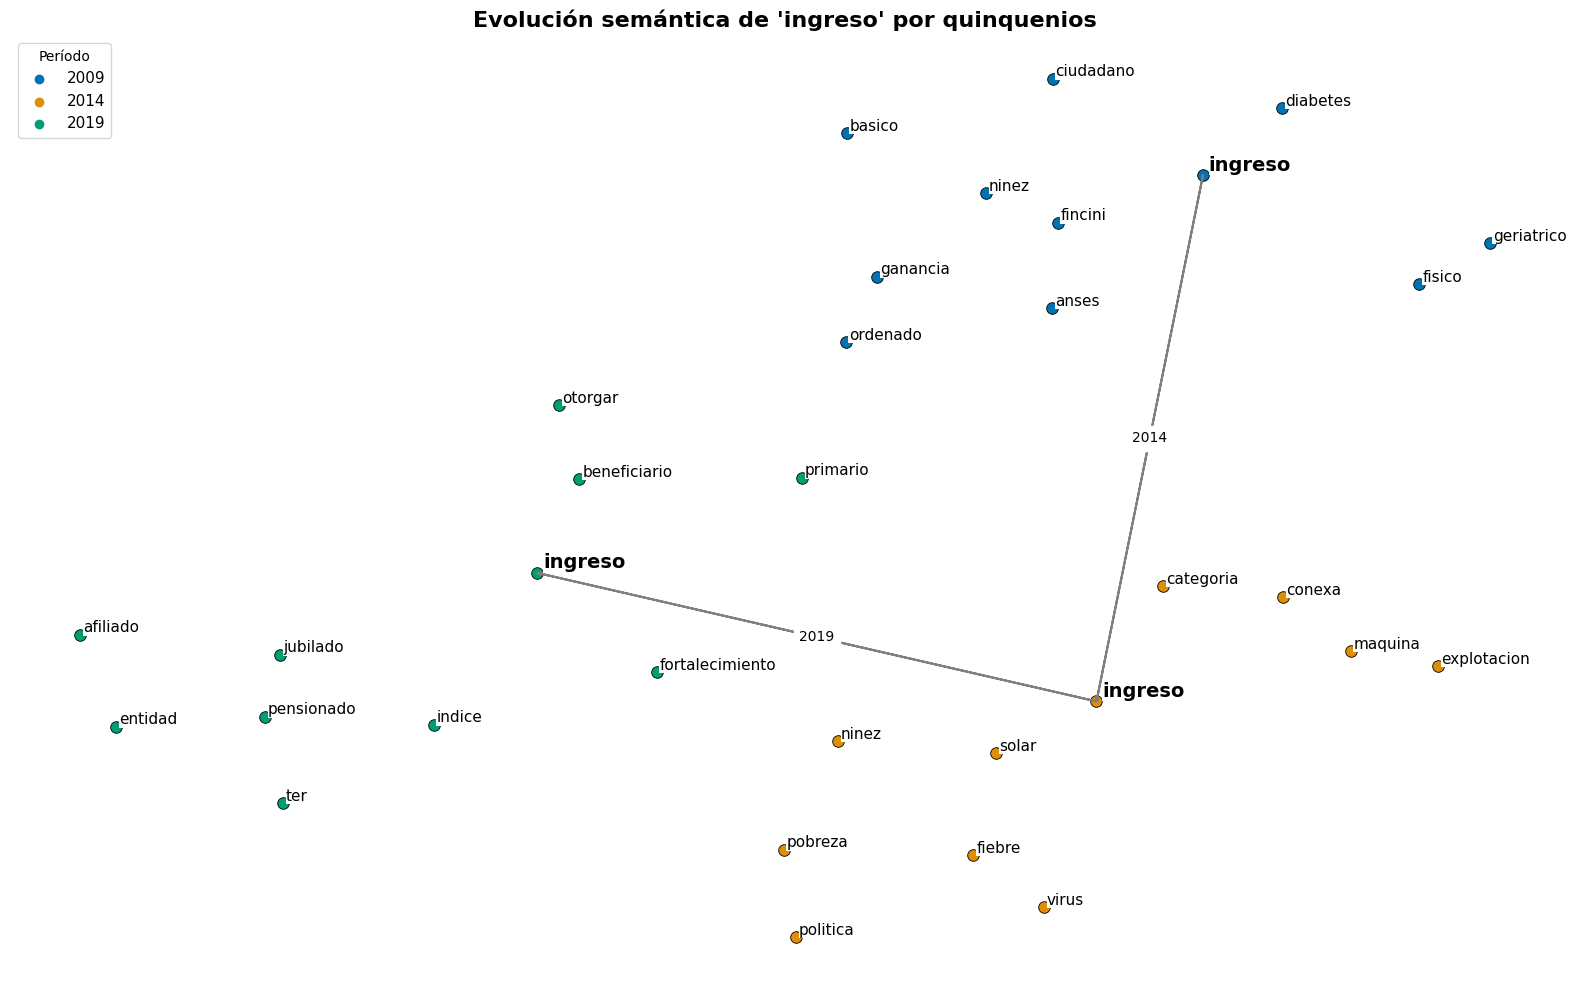

2009
[('permanencia', 0.8087295889854431), ('acompanante', 0.800499677658081), ('proceso', 0.7034876346588135), ('rotavirus', 0.6696349382400513), ('prohibir', 0.6683939099311829), ('directo', 0.6532436013221741), ('parto', 0.6381510496139526), ('nacimiento', 0.6372426152229309), ('indirecto', 0.6362025737762451), ('vacunacion', 0.6177997589111328)]
2014
[('calendario', 0.6840139031410217), ('vacunacion', 0.6061343550682068), ('vacuna', 0.5750141143798828), ('juvenil', 0.5613644123077393), ('infanto', 0.5564231276512146), ('comprendido', 0.5403817296028137), ('area', 0.5379166603088379), ('fiebre', 0.5215655565261841), ('administracion', 0.5032964944839478), ('profilaxis', 0.5027137398719788)]
2019
[('potable', 0.6174117922782898), ('presupuesto', 0.5946380496025085), ('agua', 0.5873957872390747), ('pensionado', 0.561424195766449), ('trabajador', 0.548194944858551), ('ter', 0.545976996421814), ('afiliado', 0.5457747578620911), ('afectado', 0.5436629056930542), ('jubilado', 0.5345073938

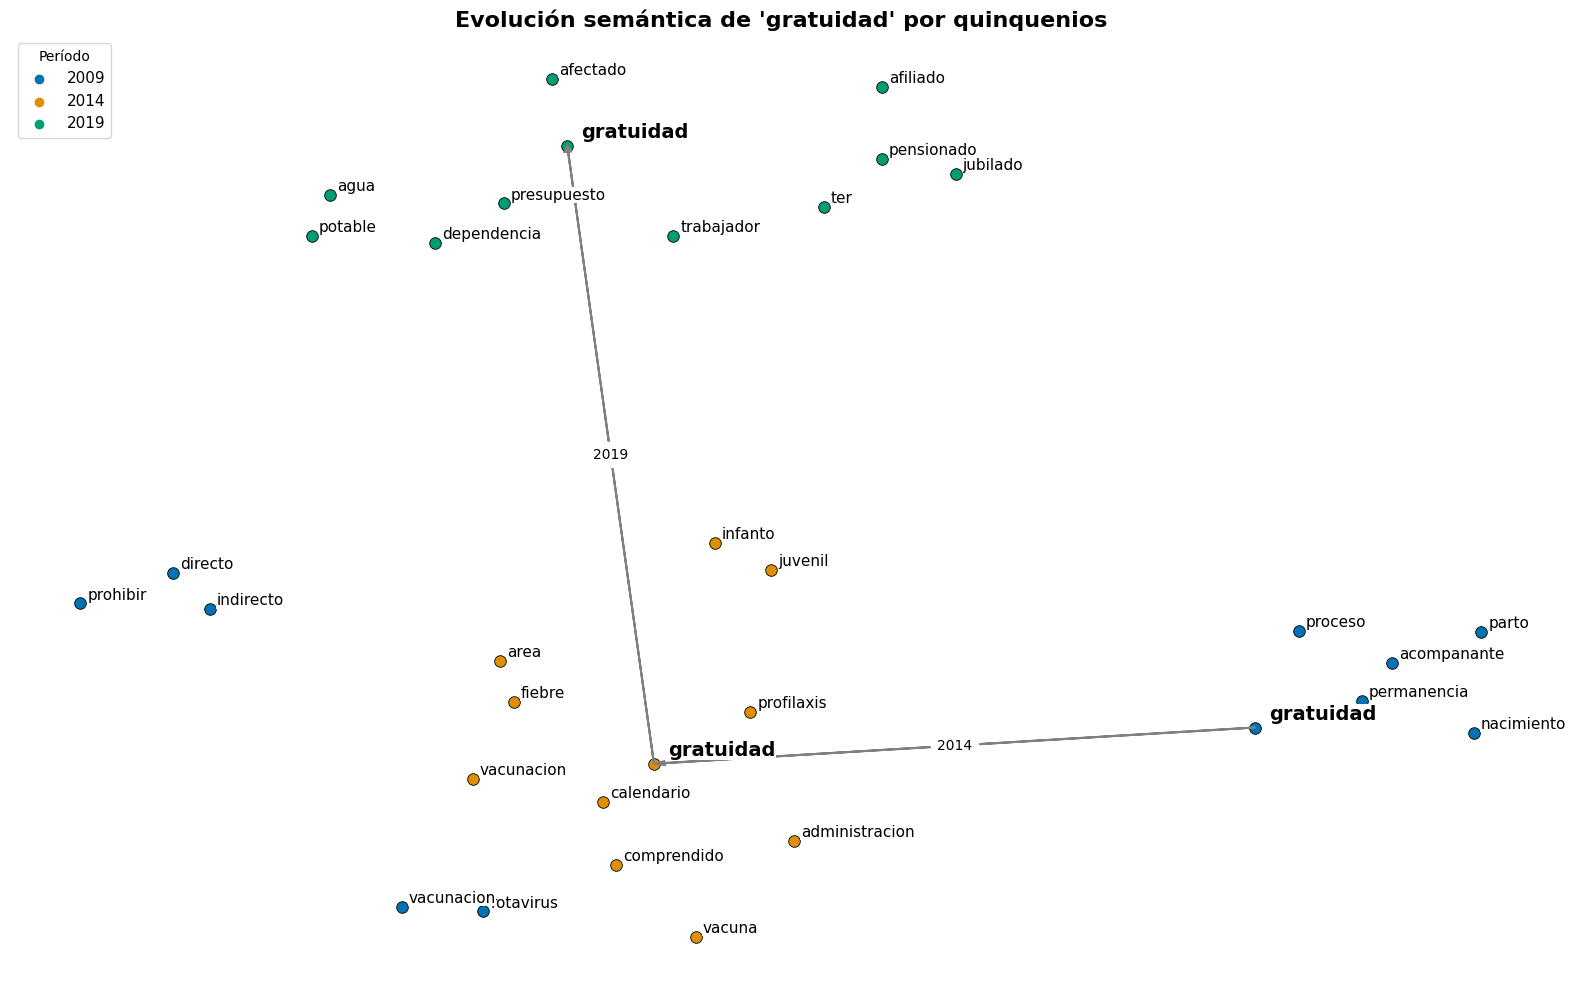

2009
[('limitacion', 0.7908945083618164), ('bioetica', 0.7807422876358032), ('cigarrillo', 0.7743152379989624), ('comercializado', 0.7722192406654358), ('prioritario', 0.7233486175537109), ('chagas', 0.7044032216072083), ('riesgo', 0.6932817101478577), ('republica', 0.65074223279953), ('tabaco', 0.6307353973388672), ('aceite', 0.6299552917480469)]
2014
[('republica', 0.7573463916778564), ('natural', 0.6315104365348816), ('comision', 0.616364061832428), ('tecnologico', 0.5911988615989685), ('objeto', 0.5752463340759277), ('basico', 0.5740185379981995), ('erupcion', 0.5552822351455688), ('ambiental', 0.5242507457733154), ('profesion', 0.523440420627594), ('volcan', 0.5155657529830933)]
2019
[('republica', 0.6878319978713989), ('tecnologia', 0.6528279781341553), ('evaluacion', 0.6446776390075684), ('pobreza', 0.6344638466835022), ('prevenibl', 0.6292681097984314), ('desfibrilador', 0.6219663023948669), ('exigencia', 0.5911200046539307), ('tumor', 0.5367932319641113), ('organismo', 0.52261

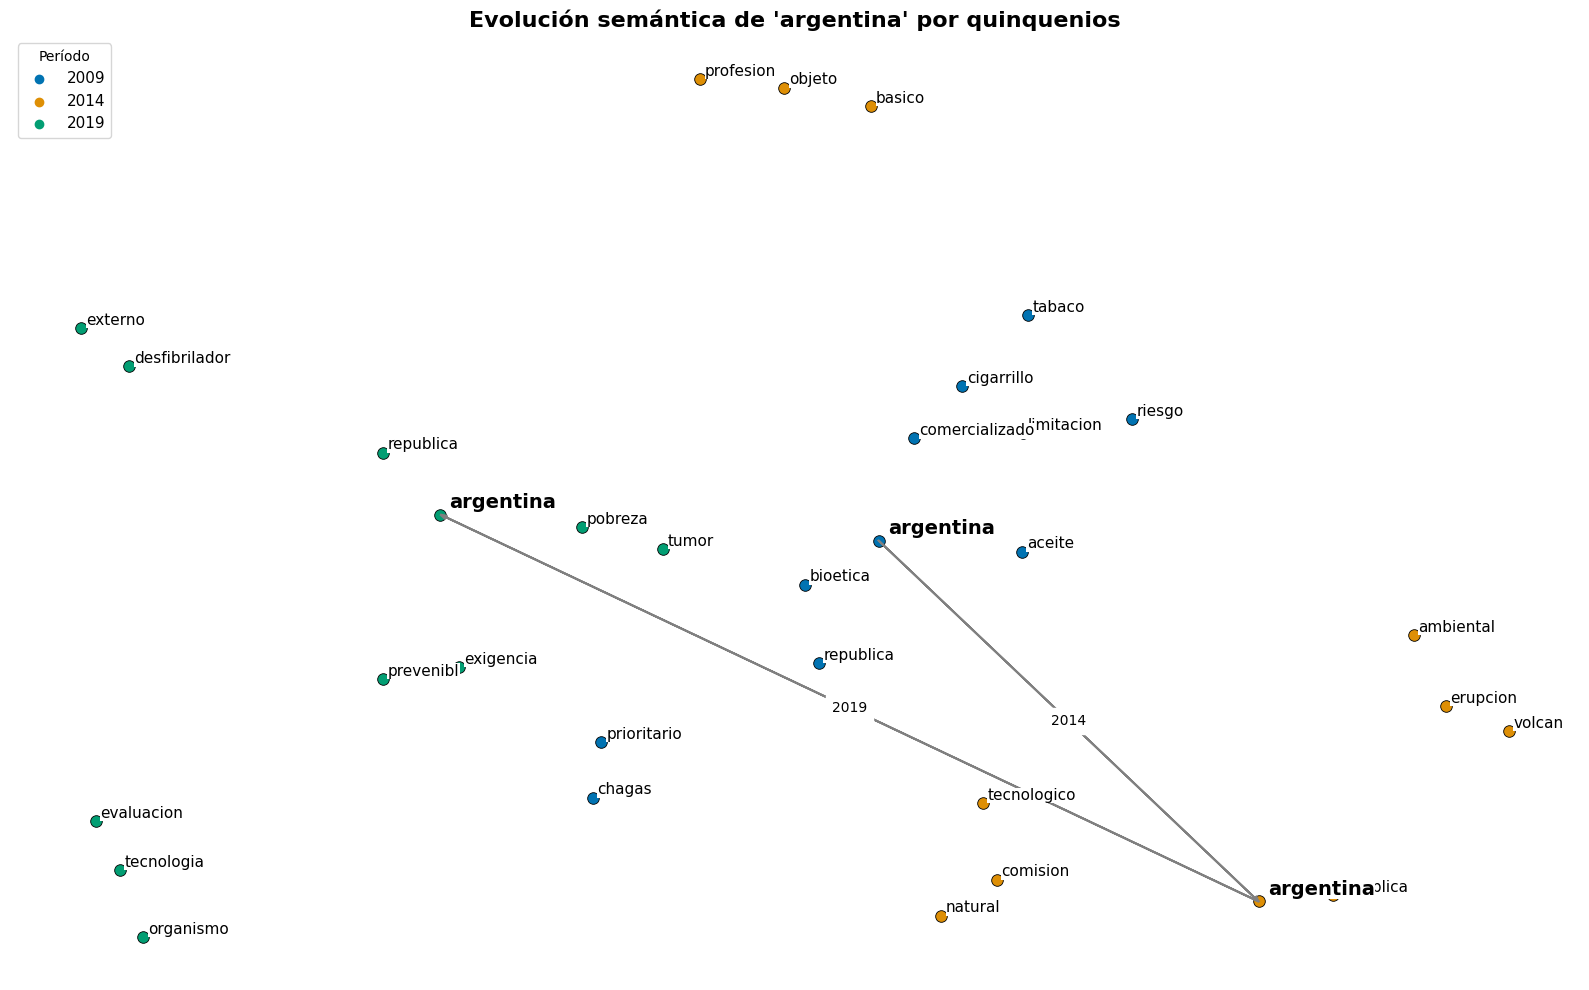

2009
[('recoleccion', 0.8310650587081909), ('vencido', 0.8257242441177368), ('capacidad', 0.7280482649803162), ('civil', 0.6902918815612793), ('odontologico', 0.6841604709625244), ('mercurio', 0.6768956184387207), ('partos', 0.6699792146682739), ('instrumento', 0.6562853455543518), ('peligroso', 0.6176881194114685), ('parto', 0.5972338318824768)]
2014
[('vencido', 0.9421037435531616), ('recoleccion', 0.936647355556488), ('inssjp', 0.6411364078521729), ('pami', 0.5976957082748413), ('resolucion', 0.596142053604126), ('pensionado', 0.5919800996780396), ('tecnologia', 0.5789263844490051), ('medicamento', 0.5595540404319763), ('jubilado', 0.5445437431335449), ('autorizar', 0.5422624945640564)]
2019
[('financiero', 0.6898142695426941), ('educacion', 0.6481752395629883), ('forma', 0.6204188466072083), ('organizacion', 0.5992527008056641), ('ter', 0.5904638767242432), ('trasplantado', 0.584762692451477), ('cualquiera', 0.564969003200531), ('fisico', 0.5442094802856445), ('actividad', 0.535817

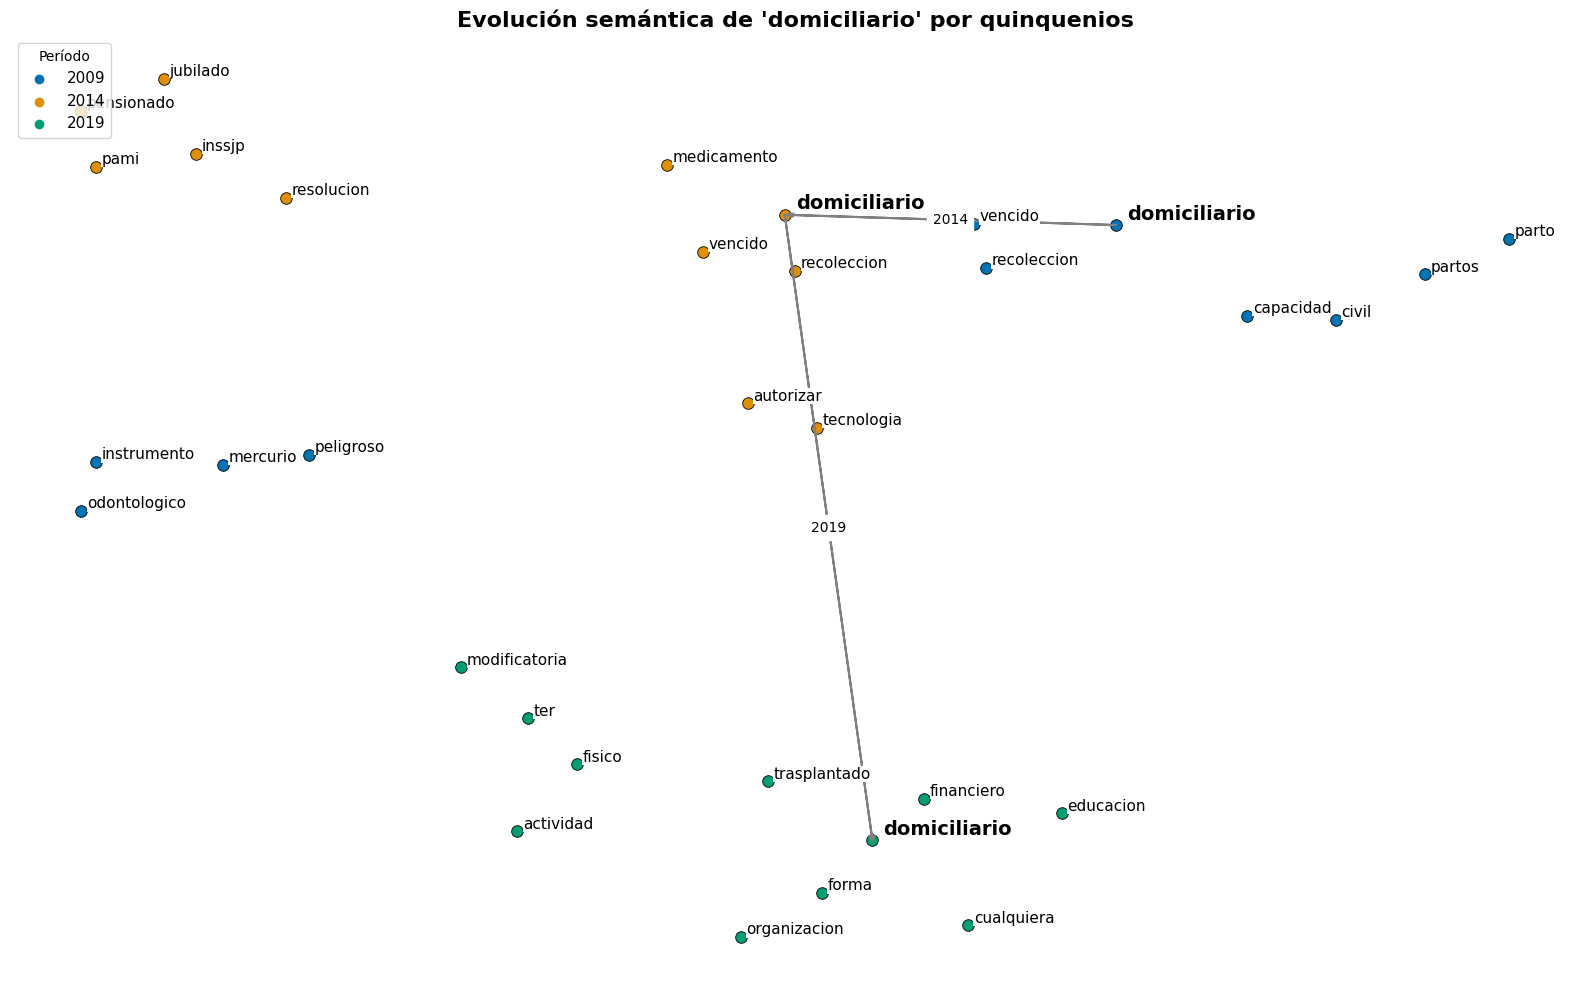

2009
[('medicacion', 0.6975869536399841), ('ostomizada', 0.6546560525894165), ('incluyendolo', 0.631233811378479), ('olivia', 0.6246256232261658), ('presupuesto', 0.6229135990142822), ('subitar', 0.6152011752128601), ('cruz', 0.6148625016212463), ('caleta', 0.6099755764007568), ('psoriasis', 0.6061798334121704), ('dispositivo', 0.6002450585365295)]
2014
[('concurrencia', 0.6630856990814209), ('subitar', 0.6358805298805237), ('desfibrilador', 0.627792477607727), ('dispositivo', 0.5810092687606812), ('externo', 0.5711357593536377), ('precio', 0.562330961227417), ('automatico', 0.5500873923301697), ('existir', 0.5473204851150513), ('incorporar', 0.5098537802696228), ('masivo', 0.49197250604629517)]
2019
[('principio', 0.6047065854072571), ('precio', 0.5609631538391113), ('publicitario', 0.49257713556289673), ('oporto', 0.4709235429763794), ('mancha', 0.4675186276435852), ('vino', 0.45988866686820984), ('manejo', 0.4570824205875397), ('llamado', 0.4568522274494171), ('produccion', 0.456490

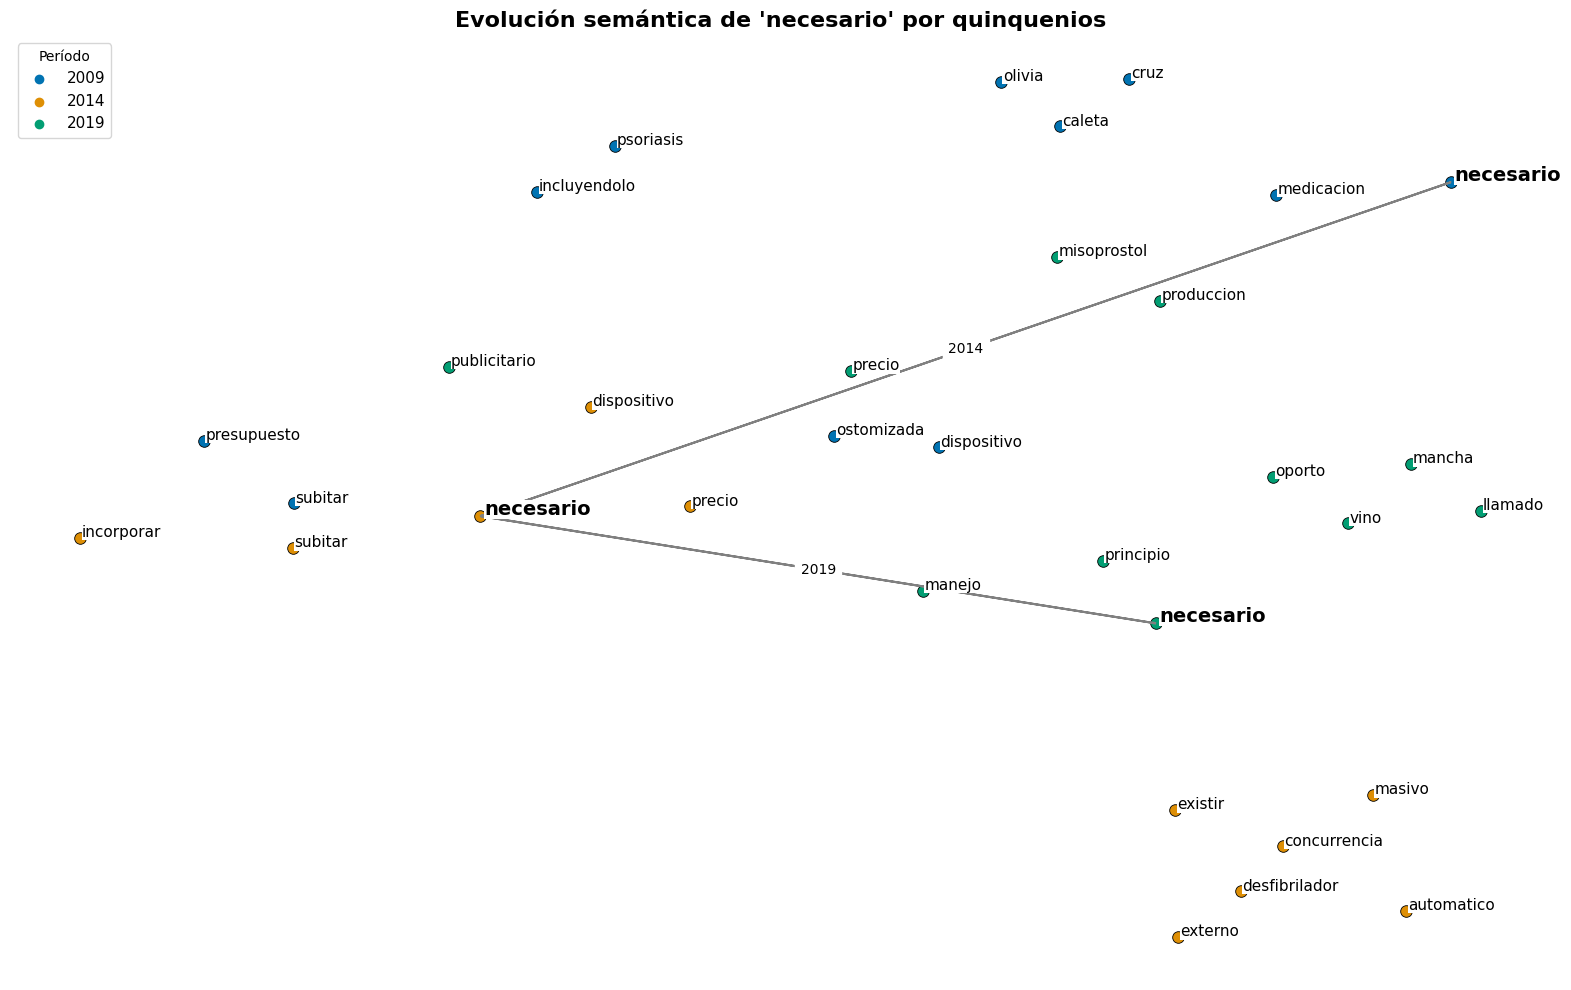

2009
[('willi', 0.68521648645401), ('spw', 0.676079511642456), ('prader', 0.6709404587745667), ('cromosomatico', 0.6435203552246094), ('existir', 0.6415783166885376), ('omision', 0.6255381107330322), ('posibilidad', 0.6113605499267578), ('global', 0.6066768169403076), ('posicionamiento', 0.5953541398048401), ('gps', 0.5908336639404297)]
2014
[('congreso', 0.6885300874710083), ('farmaceutico', 0.682367742061615), ('profesion', 0.6679563522338867), ('especialidad', 0.6660743951797485), ('cumplimiento', 0.6286411285400391), ('afiliado', 0.5804004073143005), ('receta', 0.5579735636711121), ('suspension', 0.5575219988822937), ('principio', 0.5514060258865356), ('terapeutico', 0.5512869358062744)]
2019
[('animal', 0.6771001815795898), ('judicial', 0.6449627876281738), ('donante', 0.6364989280700684), ('sangre', 0.5737289190292358), ('alcoholica', 0.5731392502784729), ('rehabilitacion', 0.5481264591217041), ('envase', 0.545299232006073), ('prepagar', 0.5344312787055969), ('banco', 0.524129390

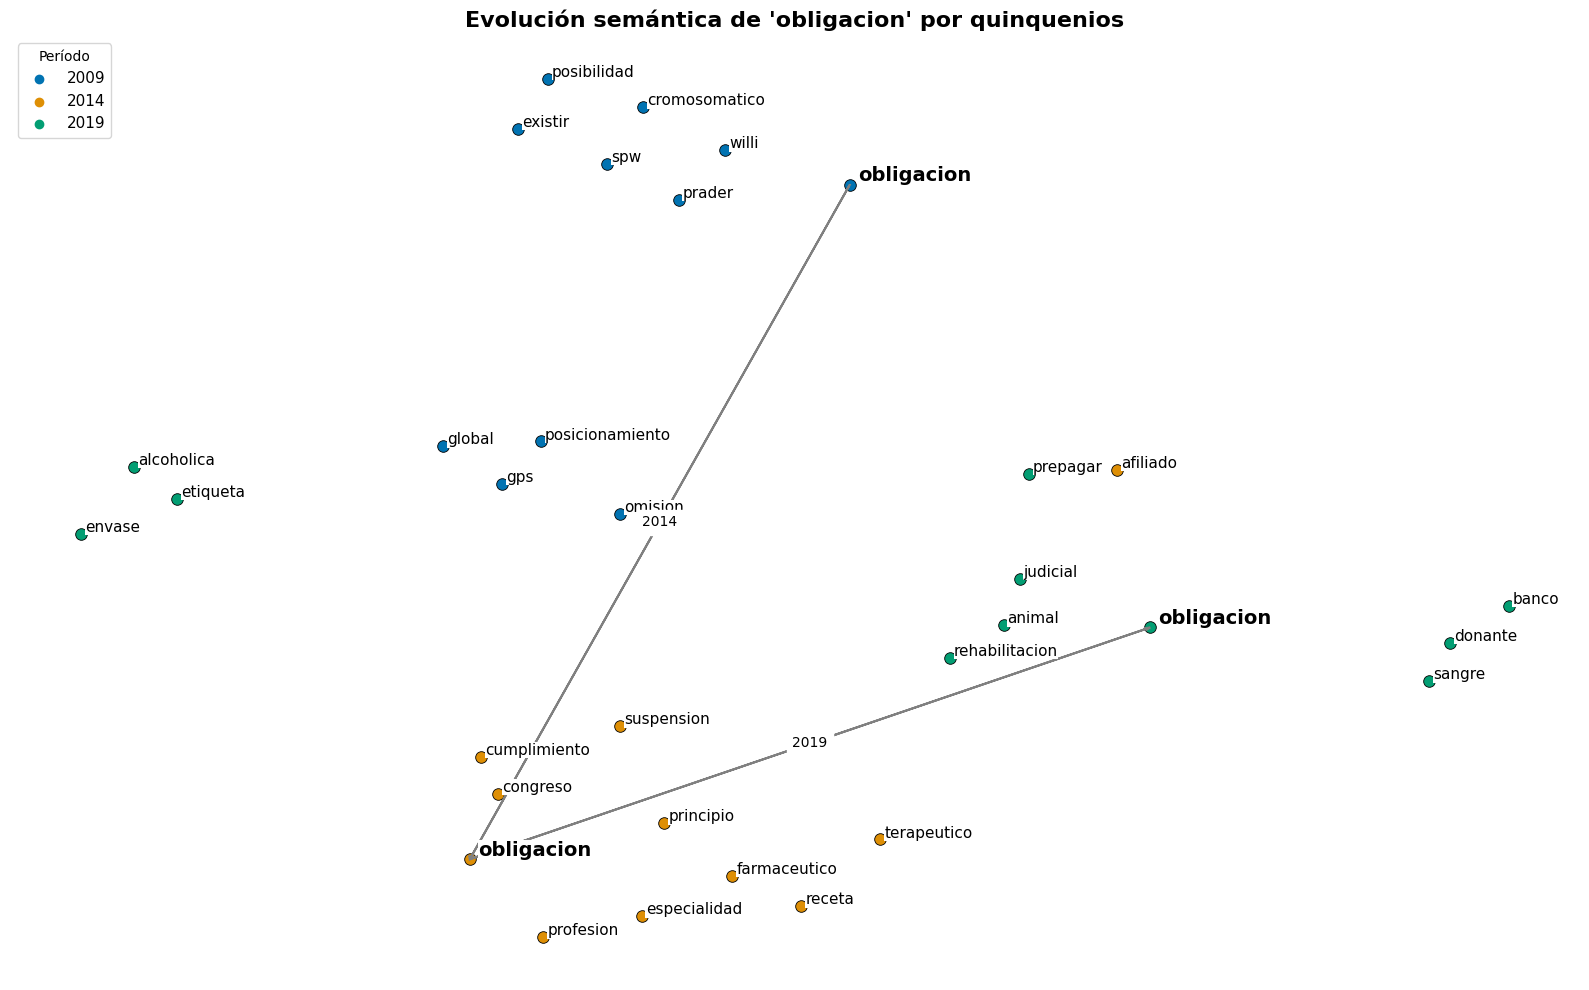

In [15]:
for palabra in top10pal : 
    plot_neighbors_tsne(palabra, vectores_alineados,modelos_alineados, [2009,2014,2019], top_k=10)

En un gráfico t-SNE las palabras más similares deberían aparecer más cerca unas de otras. Pero en la práctica, hay varios factores que pueden distorsionar esta expectativa.

**Para tener en cuenta**
¿Cuáles vecinos persisten entre períodos? (mismo contexto).
¿Qué palabras nuevas aparecen en los vecinos más similares? (nuevos usos).
¿Cuáles se desvanecen o ya no son vecinos relevantes?
¿Qué tan cohesivo o disperso es el grupo de vecinos?

comunitario 	0.394368 ->	0.278242

materia 	0.295281 ->	0.387141

tipo 	0.362660 ->	0.324483

legal 	0.236390 ->	0.544586

ingreso 	0.372726 ->	0.412960

gratuidad 	0.519763 ->	0.338310

argentina 	0.442295 ->	0.437635

domiciliario 	0.530396 ->	0.352300

necesario 	0.511345 ->	0.376819

obligacion 	0.534139 ->	0.377334

## Análisis proyectos de ley asociados a términos con cambio fuerte y moderado

In [16]:
# Abrir
with open(os.getenv("DIR_DATOS_PROCESADOS") + 'base_texto_df_ley_0924.pkl', 'rb') as file: 
    basetexto_df = pickle.load(file)

basetexto_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Proyecto.ID,35179,35179,HCDN246858,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título,35179,33168,JUICIO POR JURADOS. CREACION.,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título procesado,35179,29558,contrato de trabajo ley numero modificacion del articulo numero sobre licencias especiales,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título normalizado,35179,28761,licencia especial,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cant_token,35179.0,NaN,NaN,NaN,21.123682,10.69187,2.0,14.0,19.0,27.0,125.0
Cant_token_normalizado,35179.0,NaN,NaN,NaN,9.76341,5.051387,0.0,6.0,9.0,12.0,57.0
Proyecto_girado_a_comisiones_SALUD,35179.0,NaN,NaN,NaN,0.12786,0.333939,0.0,0.0,0.0,0.0,1.0
Proyecto_SALUD,35179.0,NaN,NaN,NaN,0.085761,0.280015,0.0,0.0,0.0,0.0,1.0
Resultado,35179,6,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,34268,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Max_Orden,35179.0,NaN,NaN,NaN,2.253504,0.822105,1.0,2.0,2.0,3.0,8.0


In [17]:
# Seleccionando IL de Salud
# Supongamos que estos son tus 3 DataFrames ya filtrados
basetotaltexto_df = basetexto_df.copy()  # todas las iniciativas
basetexto_df = basetexto_df[basetexto_df['Proyecto_SALUD']==1]
print("Conj. de datos de proyecto_SALUD con Nan en Período:",basetexto_df.shape)
basetexto_df = basetexto_df[~basetexto_df['Periodo'].isna()]
print("Conj. de datos de proyecto_SALUD sin Nan en Período:",basetexto_df.shape)

Conj. de datos de proyecto_SALUD con Nan en Período: (3017, 14)
Conj. de datos de proyecto_SALUD sin Nan en Período: (2848, 14)


In [18]:
pal = set(['materia', 'legal', 'declaracion']).union(set(['acompanante', 'dengue', 'recurso' ,'tipo' ,'patologia', 'comunitario','empleo', 'ingreso' ,'territorio']))
pal = pal.union(set( ['comunitario', 'adecuado', 'dispositivo'])).union(set(['necesario', 'materia', 'suplemento', 'obligacion' ,'tipo', 'gratuidad','forma' ,'domiciliario' ,'pais' ,'accesibilidad']))
pal = pal.union(set(top10pal))
pal = list(pal)  

In [19]:
# Convertimos a minúscula y verificamos si la palabra aparece en el título
for palabra in pal:
    basetexto_df[palabra] = basetexto_df['Título normalizado'].str.contains(rf'\b{palabra}\b', case=False)

In [20]:
proyectos_relevantes = basetexto_df[basetexto_df[pal].any(axis=1)]
print("Cantidad de proyectos asociados a las palabras con cambio semántico':" ,proyectos_relevantes.shape[0])
print("% :" , round((proyectos_relevantes.shape[0]/basetexto_df.shape[0]) * 100,2))

Cantidad de proyectos asociados a las palabras con cambio semántico': 352
% : 12.36


In [21]:
#basetexto_df.columns

In [25]:
frecuencias_df = basetexto_df[['Año',
        'adecuado', 'pais', 'patologia', 'acompanante', 'dengue',
       'dispositivo', 'gratuidad', 'empleo', 'materia', 'necesario', 'ingreso',
       'argentina', 'suplemento', 'accesibilidad', 'obligacion', 'legal',
       'domiciliario', 'forma', 'recurso', 'tipo', 'declaracion',
       'comunitario', 'territorio']].groupby(['Año']).sum().T#reset_index()
frecuencias_df['total'] = frecuencias_df.sum(axis=1) 
frecuencias_df = frecuencias_df.sort_values('total', ascending=True)
# Cantidad de proyectos por año (para normalizar)
#total_proyectos_por_anio = basetexto_df.groupby('Año').size()
# frecuencia_df tiene palabras como índice y años como columnas (frecuencia absoluta)
#frecuencia_relativa_df = frecuencias_df.div(total_proyectos_por_anio, axis=1) * 100  # multiplicamos por 100 para %
frecuencia_relativa_df = frecuencias_df.div(frecuencias_df['total'], axis=0) * 100  # multiplicamos por 100 para %
frecuencia_relativa_df = frecuencia_relativa_df.drop(columns='total')
# Ordenar por promedio total para ordenar mejor las barras
#frecuencia_relativa_df['Promedio'] = frecuencia_relativa_df.mean(axis=1)
#frecuencia_relativa_df = frecuencia_relativa_df.sort_values('Promedio', ascending=True).drop(columns='Promedio')

In [26]:
frecuencias_df

Año,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,total
adecuado,1,0,0,0,2,0,2,0,0,0,1,1,1,0,2,0,10
empleo,2,0,0,1,1,3,1,1,0,1,0,0,0,0,0,0,10
accesibilidad,0,1,0,0,1,0,1,2,0,2,0,2,0,2,0,0,11
declaracion,3,0,0,3,1,1,0,2,0,1,0,1,0,0,0,0,12
acompanante,0,1,0,1,1,1,0,3,1,2,0,1,0,0,1,0,12
dispositivo,0,0,1,1,1,1,1,0,2,0,0,2,2,0,1,0,12
gratuidad,0,2,0,2,1,1,0,0,0,1,1,4,0,0,0,0,12
materia,0,0,1,0,1,1,3,0,1,1,1,1,0,1,1,0,12
recurso,2,1,1,3,0,0,1,0,1,0,1,1,1,1,0,0,13
suplemento,0,2,1,0,1,1,1,1,1,2,2,1,0,0,0,0,13


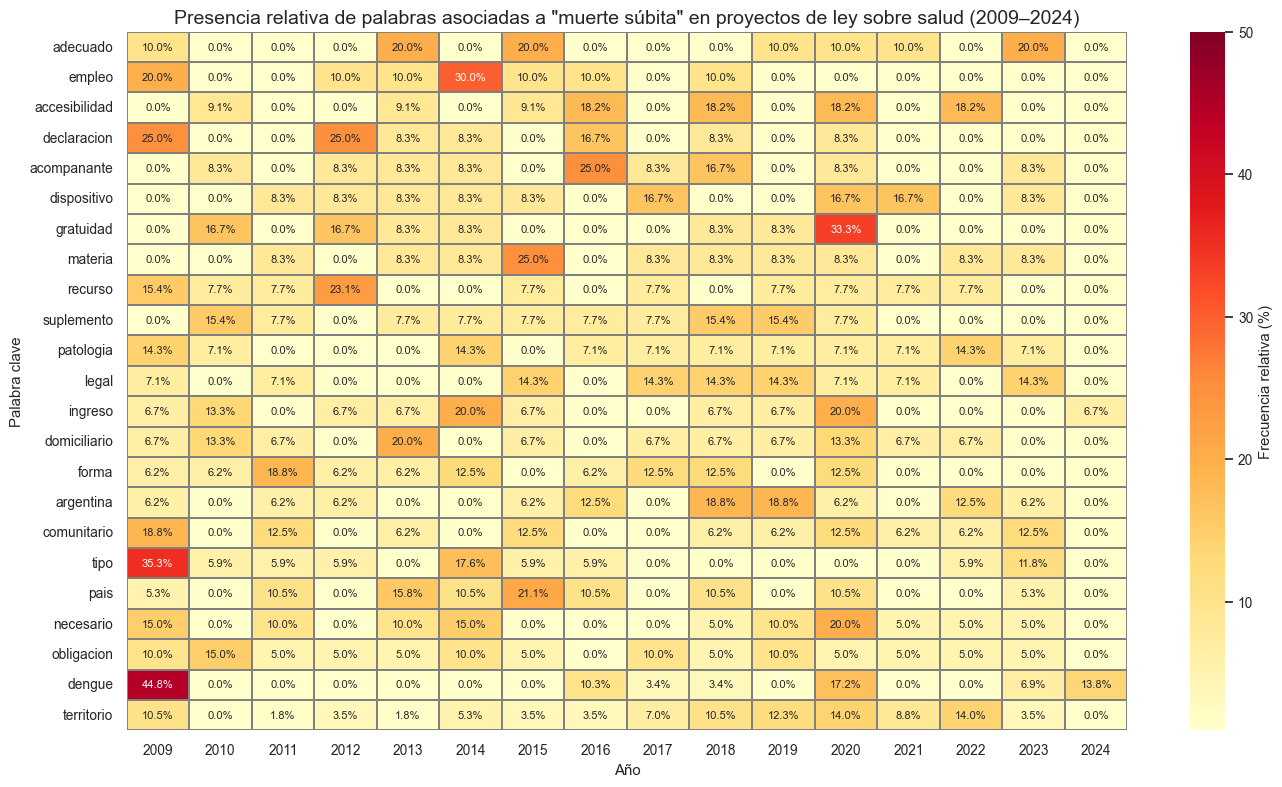

In [27]:
plt.figure(figsize=(14, 8))
sns.set(font_scale=0.9)

# Crear una versión formateada como texto con % para anotar
annot_text = frecuencia_relativa_df.round(1).astype(str) + '%'

# Paleta perceptualmente uniforme, buena para datos proporcionales
sns.heatmap(
    frecuencia_relativa_df,
    cmap="YlOrRd",           # o usa "viridis", "cividis" para daltónicos
    linewidths=0.3,
    linecolor='gray',
    cbar_kws={'label': 'Frecuencia relativa (%)'},
    vmin=1,                  # valor mínimo en escala de color
    vmax=50,                 # valor máximo
    annot=annot_text,  # Mostrar los valores como texto
    fmt='',             # Ya están formateados como string
    annot_kws={"size": 8}  # Tamaño del texto en las celdas
)
plt.title('Presencia relativa de palabras asociadas a "muerte súbita" en proyectos de ley sobre salud (2009–2024)', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Palabra clave')
plt.tight_layout()
plt.show()

In [28]:
def mostrar_ejemplos_contextuales_titulos(df, palabra, periodo, n=5):
    """
    Muestra ejemplos de títulos que contienen una palabra específica en un periodo.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'titulo' (o la columna de títulos) y 'periodo'.
        palabra (str): La palabra para buscar en los títulos (insensible a mayúsculas/minúsculas).
        periodo (int): El periodo de interés.
        n (int): Número de ejemplos a mostrar.
    """
    df_periodo = df[df['Periodo_5anios'] == periodo]
    titulos_con_palabra = df_periodo[df_periodo['Título normalizado'].str.lower().str.contains(palabra.lower(), na=False)]

    if not titulos_con_palabra.empty:
        print(f"\nEjemplos de títulos conteniendo '{palabra}' en el periodo {periodo}:")
        display(titulos_con_palabra[['Título','Título normalizado']].head(n))
    
    else:
        print(f"No se encontraron títulos conteniendo '{palabra}' en el periodo {periodo}.")


**Comunitario**

In [29]:
proyectos_relevantes.loc[proyectos_relevantes['comunitario']==True,['Proyecto.ID','Año','Título','Resultado'],].sort_values(by='Año', ascending = False)

,Proyecto.ID,Año,Título,Resultado
2536,HCDN270295,2023,"EMERGENCIA ALIMENTARIA NACIONAL - LEY 27519 - MODIFICACIONES DEL ARTICULO 6 SOBRE PRIORIZAR LOS PAGOS, SIMPLIFICAR Y AGILIZAR LOS PROCEDIMIENTOS ADMINISTRATIVOS Y REDUCIR LOS PLAZOS DE LAS LICITACIONES PUBLICAS DEL ESTADO DE COMPRAS DE ALIMENTOS SECOS Y FRESCOS, PARA COMEDORES Y MERENDEROS INSCRIPTOS EN EL REGISTRO NACIONAL COMUNITARIO DE ORGANIZACIONES DE LA SOCIEDAD CIVIL (RENACOM).",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
2791,HCDN268843,2023,REGULACION DEL EJERCICIO DEL PROMOTOR COMUNITARIO EN SALUD / AGENTE SANITARIO.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
4001,HCDN264031,2022,CREASE LA FIGURA DE PROMOTOR/A COMUNITARIO/A DE SALUD Y AGENTE SANITARIO/A - LEY DANIEL CAPPONI -.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
6175,HCDN254497,2021,"""PROMOTOR / A COMUNITARIA EN SALUD"". CREACION.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
8250,HCDN245350,2020,CREASE EL PROGRAMA DE ACOMPAÑAMIENTO Y CAPACITACION A REFERENTES COMUNITARIOS.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
9394,HCDN241020,2020,"OTORGAR EL PAGO DE UNA ASIGNACION DE RECONOCIMIENTO NO REMUNERATIVA A TRABAJADORES DE MERENDEROS Y COMEDORES COMUNITARIOS, QUE DESARROLLEN TAREAS DURANTE LA EMERGENCIA SANITARIA EN VIRTUD DE LA PANDEMIA POR COVID-19.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
10784,HCDN235425,2019,"INCREMENTESE EL PRESUPUESTO PARA LA PROVISION DE ALIMENTOS A COMEDORES POPULARES, COMUNITARIOS Y ESCOLARES.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
15040,HCDN212408,2018,"""ORGANISMO NACIONAL DE PRESTACION SANITARIA COMUNITARIA"". CREACION EN EL AMBITO DEL MINISTERIO DE SALUD DE LA NACION.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
20807,HCDN181316,2015,"SALUD MENTAL - LEY 26657 -. MODIFICACION DEL ARTICULO 11, SOBRE AMPLIAR LAS ACCIONES DE PROMOCION DEL DESARROLLO A LA ATENCION EN SALUD MENTAL COMUNITARIA.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
20942,HCDN180643,2015,"""DIA DE LA MEDICINA COMUNITARIA ARGENTINA"". INSTITUYASE COMO TAL AL 4 DE NOVIEMBRE DE CADA AÑO.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN


**Territorio**

In [31]:
proyectos_relevantes.loc[proyectos_relevantes['territorio']==True,['Proyecto.ID','Año','Título','Resultado'],].sort_values(by='Año', ascending = False)

,Proyecto.ID,Año,Título,Resultado
2551,HCDN270174,2023,DECLARESE EL ESTADO DE EMERGENCIA SANITARIA EN SALUD MENTAL Y ADICCIONES EN TODO EL TERRITORIO NACIONAL Y POR EL TERMINO DE UN AÑO PRORROGABLE.-,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
3608,HCDN265869,2023,INSTALACION DE BANCOS DE LECHE HUMANA EN TODO EL TERRITORIO NACIONAL.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
3898,HCDN264526,2022,REGIMEN FEDERAL DE MEDICINA FETAL EN TODO EL TERRITORIO NACIONAL.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
3959,HCDN264242,2022,"REGIMEN DE LEGALIZACION DEL USO DEL CANNABIS, SUS SEMILLAS Y DERIVADOS EN TODO EL TERRITORIO NACIONAL.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
5670,HCDN256159,2022,"MARCO REGULATORIO PARA EL CULTIVO, PRODUCCION, DISTRIBUCION, COMERCIALIZACION Y ADQUISICION A CUALQUIER TITULO DEL CANNABIS Y SUS DERIVADOS EN TODO EL TERRITORIO NACIONAL. REGIMEN.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
5684,HCDN256154,2022,MARCO REGULATORIO PARA EL FUNCIONAMIENTO DE CASAS DE PARTOS Y NACIMIENTOS EN EL TERRITORIO NACIONAL. IMPLEMENTACION.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
5899,HCDN255573,2022,PROHIBICION DE LA VENTA Y EXPENDIO DE BEBIDAS ENERGIZANTES A MENORES DE 18 AÑOS EN TODO EL TERRITORIO DE LA NACION.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
5965,HCDN255307,2022,"DECLARAR LA EMERGENCIA NACIONAL EN MATERIA DE CONSUMOS PROBLEMATICOS, PARA TODO EL TERRITORIO DE LA REPUBLICA ARGENTINA POR UN PERIODO DE 5 AÑOS.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
6013,HCDN255085,2022,"PROHIBASE EN TODO EL AMBITO DEL TERRITORIO DE LA REPUBLICA ARGENTINA LA EXIGENCIA DEL ""PASE SANITARIO"".",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
6019,HCDN255065,2022,CREAR EL PROGRAMA DE FORTALECIMIENTO SANITARIO -PFS- EN EL AMBITO DEL TERRITORIO NACIONAL.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN


**Gratuidad**

In [32]:
proyectos_relevantes.loc[proyectos_relevantes['gratuidad']==True,['Proyecto.ID','Año','Título','Resultado'],].sort_values(by='Año', ascending = False)

,Proyecto.ID,Año,Título,Resultado
9229,HCDN241724,2020,"DERECHO HUMANO AL AGUA POTABLE Y AL SANEAMIENTO, GRATUIDAD DE SU CONSUMO EN ESTABLECIMIENTOS GASTRONOMICOS Y PUBLICOS.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
9552,HCDN240483,2020,BOLETO ESPECIAL POR PANDEMIA Y LA GRATUIDAD EN LOS PEAJES DE RUTAS NACIONALES PARA LOS TRABAJADORES DE ACTIVIDADES ESENCIALES. CREACION.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
9789,HCDN239129,2020,"GRATUIDAD DEL TRANSPORTE PUBLICO DE PASAJEROS PARA LOS AGENTES DE SALUD, EN EL MARCO DE LA EMERGENCIA SANITARIA COMO CONSECUENCIA DE LA PANDEMIA DEL CORONAVIRUS - COVID-19 -",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
9801,HCDN239103,2020,"GRATUIDAD DEL TRANSPORTE PARA PERSONAS AFECTADAS A LA REALIZACION DE ACTIVIDADES ESENCIALES EN EL MARCO DE LA EMERGENCIA SANITARIA COMO CONSECUENCIA DE LA PANDEMIA DEL ""CORONAVIRUS - COVID-19 -""",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
11212,HCDN233306,2019,GRATUIDAD EN MEDICAMENTOS PARA AFILIADOS AL INSTITUTO NACIONAL DE SEGURIDAD SOCIAL PARA JUBILADOS Y PENSIONADOS CON INGRESOS MENSUALES QUE NO SUPEREN EL INDICE DE LA CANASTA BASICA TOTAL DETERMINADA POR EL I.N.D.E.C.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
13703,HCDN219233,2018,PACIENTES ONCOLOGICOS EN TRATAMIENTO. SE ESTABLECE LA GRATUIDAD DE LOS SERVICIOS DE TRANSPORTES TERRESTRES Y AEREOS. (REPRODUCCION DEL EXPEDIENTE 7543-D-16).,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
25208,HCDN160312,2014,CALENDARIO NACIONAL DE VACUNACION: INCORPORACION DE LA OBLIGATORIEDAD Y GRATUIDAD DE LA ADMINISTRACION DE LA VACUNA CONTRA EL ROTAVIRUS PARA TODOS LOS NIÑOS HASTA LOS 18 MESES (REPRODUCCION DEL EXPEDIENTE 8146-D-12).,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
25769,HCDN158409,2013,"LEY 25929, DE PROTECCION DEL EMBARAZO Y DEL RECIEN NACIDO: MODIFICACION DEL INCISO G) DEL ARTICULO 2, SOBRE GRATUIDAD DE LA PERMANENCIA DEL ACOMPAÑANTE DE LA MUJER EN SITUACION DE PARTO.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
27603,HCDN144109,2012,CALENDARIO NACIONAL DE VACUNACION: INCORPORACION DE LA OBLIGATORIEDAD Y GRATUIDAD DE LA ADMINISTRACION DE LA VACUNA CONTRA EL ROTAVIRUS PARA TODOS LOS NIÑOS HASTA LOS 18 MESES,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
29629,HCDN133586,2012,"DERECHOS EN LOS ESTABLECIMIENTOS DE SALUD PUBLICA Y PRIVADA, DURANTE EL PROCESO DE NACIMIENTO - LEY 25929 -. MODIFICACION DEL ARTICULO 2, SOBRE GRATUIDAD DE LA PERMANENCIA DEL ACOMPAÑANTE DE LA MUJER EN SITUACION DE PARTO.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
